# Data-Driven Investment Intelligence Using NIFTY-50 Market Data

## Complete Project Notebook

This notebook implements a complete **AI-powered investment intelligence platform** using historical NIFTY-50 stock market data.

The solution covers the major requirements of the problem statement:

### Mandatory Tasks
1. **Stock Predictor / Ranker Engine**
   - Forecasts future 30-day stock behaviour using historical market data.
   - Builds a LightGBM ranking model to rank stocks by expected future relative performance.
   - Uses time-based validation to avoid leakage.

2. **Portfolio Construction Module**
   - Generates portfolios for:
     - Conservative investor
     - Balanced investor
     - Aggressive investor
   - Provides equal-weight allocations.
   - Justifies recommendations using model score, momentum, volatility, RSI, and industry context.

3. **Risk Assessment Module**
   - Calculates volatility, annualized volatility, Sharpe ratio, Sortino ratio, negative return rate, and non-overlapping 30-day max drawdown.

### Optional Tasks Covered
1. **Explainable AI Framework**
   - Feature importance from the LightGBM Ranker.
   - Natural-language explanations for stock recommendations.

2. **Personalized Investment Strategies**
   - Investor-profile-based portfolio logic.

3. **Market Anomaly Detection**
   - Unusual volume detection.
   - Volatility spike detection.
   - Rolling 60-day drawdown anomaly detection.

4. **Working Prototype**
   - Generates a Streamlit dashboard app file.

## 1. Environment Setup

Install required packages if needed. In Google Colab, run the installation cell below.

In [7]:
# Run this cell if required
!pip install lightgbm streamlit joblib -q

In [8]:
# Core imports

import os
import glob
import zipfile
import shutil
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

import lightgbm as lgb
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 2. Data Upload / Extraction

The expected dataset files are:

- `NIFTY50_all.csv`
- `stock_metadata.csv`

If you are using Google Colab and the dataset is uploaded as a ZIP file, run the upload/extraction cell.
If the dataset is already extracted, skip the upload cell and directly set `RAW_DATA_PATH`.

In [9]:
# Optional Colab ZIP upload cell
# Run only if your dataset is in ZIP format on your local system.

try:
    from google.colab import files

    RUN_UPLOAD = True  # Change to True if you want to upload ZIP manually

    if RUN_UPLOAD:
        uploaded = files.upload()
        zip_file_name = list(uploaded.keys())[0]

        RAW_DATA_PATH = "/content/data/raw"
        os.makedirs(RAW_DATA_PATH, exist_ok=True)

        zip_path = f"/content/{zip_file_name}"
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(RAW_DATA_PATH)

        print("ZIP extracted successfully.")
        print("Extracted files:", os.listdir(RAW_DATA_PATH)[:20])
except Exception as e:
    print("Upload cell skipped or not running in Colab:", e)

Saving archive.zip to archive.zip
ZIP extracted successfully.
Extracted files: ['KOTAKBANK.csv', 'WIPRO.csv', 'SBIN.csv', 'stock_metadata.csv', 'GRASIM.csv', 'HINDUNILVR.csv', 'GAIL.csv', 'ULTRACEMCO.csv', 'AXISBANK.csv', 'NTPC.csv', 'INFY.csv', 'HDFC.csv', 'NIFTY50_all.csv', 'HINDALCO.csv', 'COALINDIA.csv', 'INDUSINDBK.csv', 'HCLTECH.csv', 'POWERGRID.csv', 'UPL.csv', 'TATASTEEL.csv']


In [10]:
# Set dataset path

if os.path.exists("/content/data/raw"):
    RAW_DATA_PATH = "/content/data/raw"
else:
    RAW_DATA_PATH = "data/raw"

stock_path = os.path.join(RAW_DATA_PATH, "NIFTY50_all.csv")
metadata_path = os.path.join(RAW_DATA_PATH, "stock_metadata.csv")

print("Raw data path:", RAW_DATA_PATH)
print("Stock file exists:", os.path.exists(stock_path))
print("Metadata file exists:", os.path.exists(metadata_path))

Raw data path: /content/data/raw
Stock file exists: True
Metadata file exists: True


## 3. Data Loading

We load the combined NIFTY-50 stock file and metadata file.

In [11]:
df = pd.read_csv(stock_path)
metadata = pd.read_csv(metadata_path)

print("Stock data shape:", df.shape)
print("Metadata shape:", metadata.shape)

print("\nStock data columns:")
print(df.columns.tolist())

print("\nMetadata columns:")
print(metadata.columns.tolist())

display(df.head())
display(metadata.head())

Stock data shape: (235192, 15)
Metadata shape: (50, 5)

Stock data columns:
['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

Metadata columns:
['Company Name', 'Industry', 'Symbol', 'Series', 'ISIN Code']


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


,Company Name,Industry,Symbol,Series,ISIN Code
0,Adani Ports and Special Economic Zone Ltd.,SERVICES,ADANIPORTS,EQ,INE742F01042
1,Asian Paints Ltd.,CONSUMER GOODS,ASIANPAINT,EQ,INE021A01026
2,Axis Bank Ltd.,FINANCIAL SERVICES,AXISBANK,EQ,INE238A01034
3,Bajaj Auto Ltd.,AUTOMOBILE,BAJAJ-AUTO,EQ,INE917I01010
4,Bajaj Finserv Ltd.,FINANCIAL SERVICES,BAJAJFINSV,EQ,INE918I01018


## 4. Data Cleaning and Metadata Integration

Steps:
- Convert date column.
- Keep equity series only.
- Sort by stock and date.
- Merge industry and company metadata.
- Fill missing metadata for historical/renamed symbols.

In [12]:
df["Date"] = pd.to_datetime(df["Date"])

# Keep only equity series
df = df[df["Series"] == "EQ"].copy()

# Sort by stock and date
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# Merge metadata
metadata_small = metadata[["Symbol", "Company Name", "Industry"]].copy()
df = df.merge(metadata_small, on="Symbol", how="left")

# Fill missing metadata for old/renamed symbols
df["Company Name"] = df["Company Name"].fillna(df["Symbol"])
df["Industry"] = df["Industry"].fillna("UNKNOWN")

print("Cleaned dataset shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Number of unique stocks:", df["Symbol"].nunique())
print("Number of unique industries:", df["Industry"].nunique())

print("\nIndustry distribution:")
display(df["Industry"].value_counts())

display(df.head())

Cleaned dataset shape: (235192, 17)
Date range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00
Number of unique stocks: 65
Number of unique industries: 14

Industry distribution:


,count
Industry,
FINANCIAL SERVICES,39911
ENERGY,33656
CONSUMER GOODS,27442
UNKNOWN,27342
AUTOMOBILE,24951
IT,20816
PHARMA,15918
METALS,15189
CEMENT & CEMENT PRODUCTS,14431


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company Name,Industry
0,2012-01-17,ADANIPORTS,EQ,135.5,137.1,141.00,135.00,140.1,140.00,138.13,1636196,2.260074e+13,18374.0,1004327.0,0.6138,Adani Ports and Special Economic Zone Ltd.,SERVICES
1,2012-01-18,ADANIPORTS,EQ,140.0,142.0,143.80,138.70,143.0,141.70,141.25,890591,1.257986e+13,15615.0,404925.0,0.4547,Adani Ports and Special Economic Zone Ltd.,SERVICES
2,2012-01-19,ADANIPORTS,EQ,141.7,144.0,150.55,143.15,149.5,149.40,146.72,1456077,2.136382e+13,31299.0,721545.0,0.4955,Adani Ports and Special Economic Zone Ltd.,SERVICES
3,2012-01-20,ADANIPORTS,EQ,149.4,151.9,157.60,150.25,155.4,155.40,153.76,1634070,2.512583e+13,23335.0,861145.0,0.5270,Adani Ports and Special Economic Zone Ltd.,SERVICES
4,2012-01-23,ADANIPORTS,EQ,155.4,155.4,155.40,145.10,146.4,146.75,149.54,1657609,2.478768e+13,12400.0,820653.0,0.4951,Adani Ports and Special Economic Zone Ltd.,SERVICES


## 5. Exploratory Data Analysis

EDA helps understand:
- Market-wide trends.
- Long-term stock performance.
- Industry-level risk-adjusted behavior.

In [13]:
OUTPUT_DIR = "nifty50_outputs"
CHART_DIR = os.path.join(OUTPUT_DIR, "charts")
DATA_DIR = os.path.join(OUTPUT_DIR, "data")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Output directory created:", OUTPUT_DIR)

Output directory created: nifty50_outputs


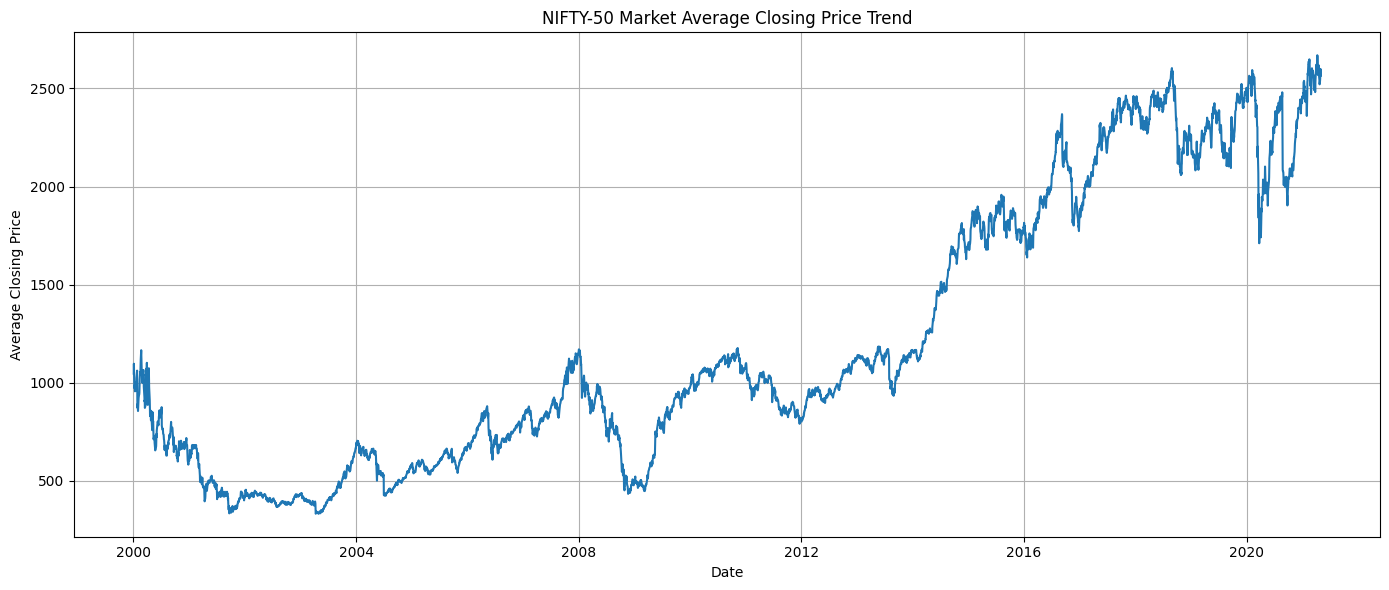

,Date,Average_Close,Average_Volume,Average_Turnover
0,2000-01-03,1046.295455,3.757107e+05,1.332511e+13
1,2000-01-04,1096.909091,7.129494e+05,3.568487e+13
2,2000-01-05,1047.637879,1.453544e+06,7.562085e+13
3,2000-01-06,1019.443939,1.061267e+06,4.924700e+13
4,2000-01-07,971.904545,1.100421e+06,3.531071e+13


In [14]:
# Market average trend

market_trend = df.groupby("Date").agg(
    Average_Close=("Close", "mean"),
    Average_Volume=("Volume", "mean"),
    Average_Turnover=("Turnover", "mean")
).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(market_trend["Date"], market_trend["Average_Close"])
plt.title("NIFTY-50 Market Average Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Average Closing Price")
plt.grid(True)
plt.tight_layout()

chart_path = os.path.join(CHART_DIR, "market_average_close_trend.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

display(market_trend.head())

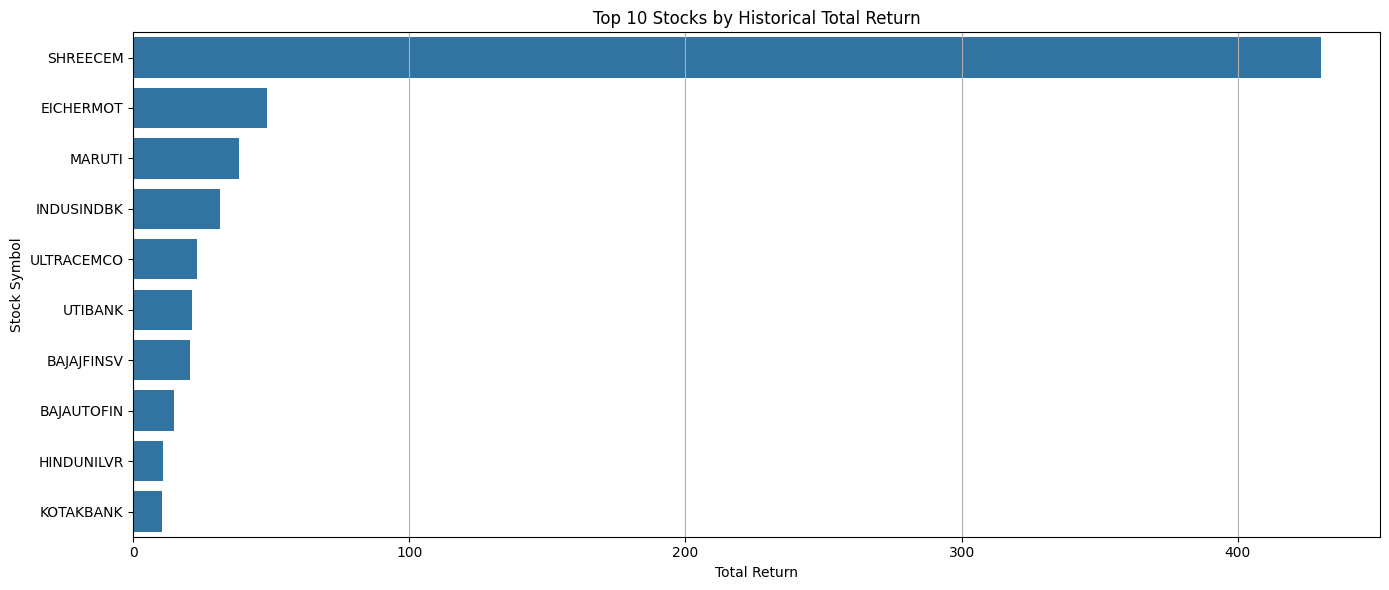

Top 10 stocks by total return:


,Symbol,Company_Name,Industry,Start_Date,End_Date,First_Close,Last_Close,Avg_Volume,Total_Return
47,SHREECEM,Shree Cement Ltd.,CEMENT & CEMENT PRODUCTS,2000-01-03,2021-04-30,64.75,27910.50,2.507495e+04,430.050193
14,EICHERMOT,Eicher Motors Ltd.,AUTOMOBILE,2000-01-03,2021-04-30,48.85,2421.65,9.628430e+04,48.573183
38,MARUTI,Maruti Suzuki India Ltd.,AUTOMOBILE,2003-07-09,2021-04-30,164.30,6455.65,1.194661e+06,38.291844
27,INDUSINDBK,IndusInd Bank Ltd.,FINANCIAL SERVICES,2000-01-03,2021-04-30,28.95,934.95,2.351251e+06,31.295337
57,ULTRACEMCO,UltraTech Cement Ltd.,CEMENT & CEMENT PRODUCTS,2004-08-24,2021-04-30,260.20,6278.95,2.476179e+05,23.131245
60,UTIBANK,UTIBANK,UNKNOWN,2000-01-03,2007-08-14,26.70,597.50,2.879499e+05,21.378277
4,BAJAJFINSV,Bajaj Finserv Ltd.,FINANCIAL SERVICES,2008-05-26,2021-04-30,509.10,11041.65,2.315312e+05,20.688568
5,BAJAUTOFIN,BAJAUTOFIN,UNKNOWN,2000-01-03,2010-09-28,50.75,793.60,1.899630e+04,14.637438
25,HINDUNILVR,Hindustan Unilever Ltd.,CONSUMER GOODS,2007-07-19,2021-04-30,197.80,2353.75,2.137848e+06,10.899646
34,KOTAKBANK,Kotak Mahindra Bank Ltd.,FINANCIAL SERVICES,2003-04-21,2021-04-30,155.20,1748.80,1.419329e+06,10.268041


Bottom 10 stocks by total return:


,Symbol,Company_Name,Industry,Start_Date,End_Date,First_Close,Last_Close,Avg_Volume,Total_Return
24,HINDLEVER,HINDLEVER,UNKNOWN,2000-01-03,2007-07-18,2307.55,198.80,1.975032e+06,-0.913848
39,MUNDRAPORT,MUNDRAPORT,UNKNOWN,2007-11-27,2012-01-16,962.90,135.50,8.090038e+05,-0.859279
22,HINDALC0,HINDALC0,UNKNOWN,2000-01-03,2007-08-24,867.45,142.00,1.092017e+06,-0.836302
62,WIPRO,Wipro Ltd.,IT,2000-01-03,2021-04-30,2724.20,492.75,2.236123e+06,-0.819121
28,INFOSYSTCH,INFOSYSTCH,UNKNOWN,2000-01-03,2011-06-28,15625.20,2865.30,1.030852e+06,-0.816623
64,ZEETELE,ZEETELE,UNKNOWN,2000-01-03,2007-02-27,1179.95,238.35,4.674488e+06,-0.798000
58,UNIPHOS,UNIPHOS,UNKNOWN,2004-01-23,2013-10-22,553.80,157.80,7.926438e+05,-0.715060
31,ITC,ITC Ltd.,CONSUMER GOODS,2000-01-03,2021-04-30,708.50,202.60,7.173165e+06,-0.714044
30,IOC,Indian Oil Corporation Ltd.,ENERGY,2000-01-03,2021-04-30,270.85,90.85,3.188201e+06,-0.664574
49,SUNPHARMA,Sun Pharmaceutical Industries Ltd.,PHARMA,2000-01-03,2021-04-30,1835.05,654.45,2.227251e+06,-0.643361


In [15]:
# Top and bottom stocks by historical total return

stock_performance = df.groupby("Symbol").agg(
    Company_Name=("Company Name", "first"),
    Industry=("Industry", "first"),
    Start_Date=("Date", "min"),
    End_Date=("Date", "max"),
    First_Close=("Close", "first"),
    Last_Close=("Close", "last"),
    Avg_Volume=("Volume", "mean")
).reset_index()

stock_performance["Total_Return"] = (
    stock_performance["Last_Close"] / stock_performance["First_Close"]
) - 1

top10_stocks = stock_performance.sort_values("Total_Return", ascending=False).head(10)
bottom10_stocks = stock_performance.sort_values("Total_Return", ascending=True).head(10)

plt.figure(figsize=(14, 6))
sns.barplot(data=top10_stocks, x="Total_Return", y="Symbol")
plt.title("Top 10 Stocks by Historical Total Return")
plt.xlabel("Total Return")
plt.ylabel("Stock Symbol")
plt.tight_layout()

chart_path = os.path.join(CHART_DIR, "top10_stocks_total_return.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Top 10 stocks by total return:")
display(top10_stocks)

print("Bottom 10 stocks by total return:")
display(bottom10_stocks)

## 6. Core Feature Engineering

This section creates return, price-action, volume, technical, market-relative, and industry-relative features.

In [16]:
# Core return, price-action, and volume features

df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# Return features
df["Return_1D"] = df.groupby("Symbol")["Close"].pct_change(1)
df["Return_5D"] = df.groupby("Symbol")["Close"].pct_change(5)
df["Return_10D"] = df.groupby("Symbol")["Close"].pct_change(10)
df["Return_20D"] = df.groupby("Symbol")["Close"].pct_change(20)
df["Return_60D"] = df.groupby("Symbol")["Close"].pct_change(60)

# Log return
df["Log_Return_1D"] = df.groupby("Symbol")["Close"].transform(
    lambda x: np.log(x / x.shift(1))
)

# Price-action features
df["High_Low_Range"] = (df["High"] - df["Low"]) / df["Close"]
df["Open_Close_Change"] = (df["Close"] - df["Open"]) / df["Open"]
df["Close_vs_VWAP"] = (df["Close"] - df["VWAP"]) / df["VWAP"]

# Volume and turnover features
df["Volume_Change_1D"] = df.groupby("Symbol")["Volume"].pct_change(1)
df["Volume_Change_5D"] = df.groupby("Symbol")["Volume"].pct_change(5)
df["Turnover_Change_1D"] = df.groupby("Symbol")["Turnover"].pct_change(1)

print("Shape after core feature creation:", df.shape)

display(df[[
    "Date", "Symbol", "Close",
    "Return_1D", "Return_5D", "Return_20D", "Return_60D",
    "High_Low_Range", "Open_Close_Change", "Close_vs_VWAP",
    "Volume_Change_1D", "Volume_Change_5D", "Turnover_Change_1D"
]].head(25))

Shape after core feature creation: (235192, 29)


,Date,Symbol,Close,Return_1D,Return_5D,Return_20D,Return_60D,High_Low_Range,Open_Close_Change,Close_vs_VWAP,Volume_Change_1D,Volume_Change_5D,Turnover_Change_1D
0,2012-01-17,ADANIPORTS,140.00,NaN,NaN,NaN,NaN,0.042857,0.021152,0.013538,NaN,NaN,NaN
1,2012-01-18,ADANIPORTS,141.70,0.012143,NaN,NaN,NaN,0.035992,-0.002113,0.003186,-0.455694,NaN,-0.443387
2,2012-01-19,ADANIPORTS,149.40,0.054340,NaN,NaN,NaN,0.049531,0.037500,0.018266,0.634956,NaN,0.698256
3,2012-01-20,ADANIPORTS,155.40,0.040161,NaN,NaN,NaN,0.047297,0.023041,0.010666,0.122241,NaN,0.176092
4,2012-01-23,ADANIPORTS,146.75,-0.055663,NaN,NaN,NaN,0.070187,-0.055663,-0.018657,0.014405,NaN,-0.013458
5,2012-01-24,ADANIPORTS,150.05,0.022487,0.071786,NaN,NaN,0.048650,0.020401,-0.001597,-0.193198,-0.182639,-0.189154
6,2012-01-25,ADANIPORTS,143.20,-0.045651,0.010586,NaN,NaN,0.060754,-0.051342,-0.011050,0.390511,1.088071,0.339724
7,2012-01-27,ADANIPORTS,147.10,0.027235,-0.015395,NaN,NaN,0.032971,0.008916,-0.003995,-0.320030,-0.131582,-0.306474
8,2012-01-30,ADANIPORTS,138.40,-0.059143,-0.109395,NaN,NaN,0.072616,-0.059143,-0.026244,-0.400788,-0.536315,-0.423311
9,2012-01-31,ADANIPORTS,146.25,0.056720,-0.003407,NaN,NaN,0.078632,0.052537,0.021513,0.704308,-0.220960,0.716732


In [17]:
# Technical indicators

def add_technical_indicators(group):
    group = group.sort_values("Date").copy()

    # Moving Averages
    group["MA_5"] = group["Close"].rolling(window=5).mean()
    group["MA_10"] = group["Close"].rolling(window=10).mean()
    group["MA_20"] = group["Close"].rolling(window=20).mean()
    group["MA_50"] = group["Close"].rolling(window=50).mean()
    group["MA_100"] = group["Close"].rolling(window=100).mean()
    group["MA_200"] = group["Close"].rolling(window=200).mean()

    # Price relative to moving averages
    group["Close_vs_MA_5"] = (group["Close"] - group["MA_5"]) / group["MA_5"]
    group["Close_vs_MA_20"] = (group["Close"] - group["MA_20"]) / group["MA_20"]
    group["Close_vs_MA_50"] = (group["Close"] - group["MA_50"]) / group["MA_50"]
    group["Close_vs_MA_200"] = (group["Close"] - group["MA_200"]) / group["MA_200"]

    # Exponential Moving Averages
    group["EMA_12"] = group["Close"].ewm(span=12, adjust=False).mean()
    group["EMA_26"] = group["Close"].ewm(span=26, adjust=False).mean()

    # MACD
    group["MACD"] = group["EMA_12"] - group["EMA_26"]
    group["MACD_Signal"] = group["MACD"].ewm(span=9, adjust=False).mean()
    group["MACD_Hist"] = group["MACD"] - group["MACD_Signal"]

    # Bollinger Bands
    group["BB_Middle"] = group["Close"].rolling(window=20).mean()
    group["BB_Std"] = group["Close"].rolling(window=20).std()
    group["BB_Upper"] = group["BB_Middle"] + 2 * group["BB_Std"]
    group["BB_Lower"] = group["BB_Middle"] - 2 * group["BB_Std"]
    group["BB_Width"] = (group["BB_Upper"] - group["BB_Lower"]) / group["BB_Middle"]
    group["BB_Position"] = (group["Close"] - group["BB_Lower"]) / (group["BB_Upper"] - group["BB_Lower"])

    # RSI 14
    delta = group["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()

    rs = avg_gain / avg_loss
    group["RSI_14"] = 100 - (100 / (1 + rs))

    # Volatility indicators
    group["Volatility_5D"] = group["Return_1D"].rolling(window=5).std()
    group["Volatility_10D"] = group["Return_1D"].rolling(window=10).std()
    group["Volatility_20D"] = group["Return_1D"].rolling(window=20).std()
    group["Volatility_60D"] = group["Return_1D"].rolling(window=60).std()

    # Momentum indicators
    group["Momentum_5D"] = group["Close"] / group["Close"].shift(5) - 1
    group["Momentum_20D"] = group["Close"] / group["Close"].shift(20) - 1
    group["Momentum_60D"] = group["Close"] / group["Close"].shift(60) - 1

    return group

df = df.groupby("Symbol", group_keys=False).apply(add_technical_indicators)

print("Shape after technical indicator creation:", df.shape)

display(df[[
    "Date", "Symbol", "Close",
    "MA_20", "MA_50", "MA_200",
    "EMA_12", "EMA_26",
    "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Width", "BB_Position",
    "RSI_14",
    "Volatility_20D",
    "Momentum_20D"
]].head(250).tail(20))

Shape after technical indicator creation: (235192, 58)


,Date,Symbol,Close,MA_20,MA_50,MA_200,EMA_12,EMA_26,MACD,MACD_Signal,MACD_Hist,BB_Width,BB_Position,RSI_14,Volatility_20D,Momentum_20D
230,2012-12-18,ADANIPORTS,142.65,131.7900,128.706,123.65425,135.976266,132.622665,3.353601,2.468176,0.885425,0.192273,0.928577,66.246851,0.025146,0.114889
231,2012-12-19,ADANIPORTS,145.25,132.8925,129.048,123.64375,137.402994,133.558023,3.844971,2.743535,1.101436,0.200797,0.963099,76.052632,0.023145,0.178977
232,2012-12-20,ADANIPORTS,140.00,133.7400,129.372,123.61300,137.802534,134.035207,3.767327,2.948294,0.819033,0.192227,0.743500,62.775616,0.025149,0.137749
233,2012-12-21,ADANIPORTS,135.65,134.3825,129.632,123.57525,137.471375,134.154821,3.316554,3.021946,0.294608,0.175507,0.553742,54.166667,0.026487,0.104642
234,2012-12-24,ADANIPORTS,135.35,134.9825,129.929,123.53425,137.145009,134.243353,2.901657,2.997888,-0.096231,0.156890,0.517353,51.219512,0.026541,0.097284
235,2012-12-26,ADANIPORTS,136.40,135.5350,130.171,123.49000,137.030392,134.403104,2.627288,2.923768,-0.296480,0.141326,0.545159,53.435115,0.026419,0.088153
236,2012-12-27,ADANIPORTS,133.80,135.7375,130.339,123.48400,136.533409,134.358430,2.174979,2.774010,-0.599031,0.135955,0.395011,48.458693,0.025895,0.031214
237,2012-12-28,ADANIPORTS,132.85,136.1075,130.527,123.49875,135.966731,134.246694,1.720036,2.563215,-0.843179,0.117589,0.296467,43.902439,0.024668,0.058988
238,2012-12-31,ADANIPORTS,135.00,136.3500,130.826,123.51825,135.818003,134.302495,1.515508,2.353674,-0.838166,0.110330,0.410260,47.472256,0.023544,0.037265
239,2013-01-01,ADANIPORTS,137.80,136.6275,131.182,123.52850,136.122926,134.561569,1.561356,2.195210,-0.633854,0.106726,0.580409,53.714982,0.023711,0.041966


In [18]:
# Cross-sectional market and industry comparison features

df = df.sort_values(["Date", "Symbol"]).reset_index(drop=True)

# Cross-sectional rank features within each date
df["Return_20D_Rank"] = df.groupby("Date")["Return_20D"].rank(pct=True)
df["Return_60D_Rank"] = df.groupby("Date")["Return_60D"].rank(pct=True)
df["Volatility_20D_Rank"] = df.groupby("Date")["Volatility_20D"].rank(pct=True)
df["Momentum_20D_Rank"] = df.groupby("Date")["Momentum_20D"].rank(pct=True)
df["RSI_14_Rank"] = df.groupby("Date")["RSI_14"].rank(pct=True)

# Daily market average features
df["Market_Return_1D"] = df.groupby("Date")["Return_1D"].transform("mean")
df["Market_Return_20D"] = df.groupby("Date")["Return_20D"].transform("mean")
df["Market_Volatility_20D"] = df.groupby("Date")["Volatility_20D"].transform("mean")

# Stock performance relative to market
df["Return_1D_vs_Market"] = df["Return_1D"] - df["Market_Return_1D"]
df["Return_20D_vs_Market"] = df["Return_20D"] - df["Market_Return_20D"]
df["Volatility_20D_vs_Market"] = df["Volatility_20D"] - df["Market_Volatility_20D"]

# Industry-level comparison features
df["Industry_Return_20D"] = df.groupby(["Date", "Industry"])["Return_20D"].transform("mean")
df["Industry_Volatility_20D"] = df.groupby(["Date", "Industry"])["Volatility_20D"].transform("mean")

df["Return_20D_vs_Industry"] = df["Return_20D"] - df["Industry_Return_20D"]
df["Volatility_20D_vs_Industry"] = df["Volatility_20D"] - df["Industry_Volatility_20D"]

print("Shape after cross-sectional feature creation:", df.shape)

display(df[[
    "Date", "Symbol", "Industry",
    "Return_20D", "Return_20D_Rank", "Return_20D_vs_Market", "Return_20D_vs_Industry",
    "Volatility_20D", "Volatility_20D_Rank", "Volatility_20D_vs_Market",
    "Momentum_20D_Rank", "RSI_14_Rank"
]].dropna().head(20))

Shape after cross-sectional feature creation: (235192, 73)


,Date,Symbol,Industry,Return_20D,Return_20D_Rank,Return_20D_vs_Market,Return_20D_vs_Industry,Volatility_20D,Volatility_20D_Rank,Volatility_20D_vs_Market,Momentum_20D_Rank,RSI_14_Rank
674,2000-02-01,ASIANPAINT,CONSUMER GOODS,0.206079,0.818182,0.168974,0.199039,0.033677,0.272727,-0.010182,0.818182,0.647059
675,2000-02-01,BAJAUTOFIN,UNKNOWN,-0.289655,0.060606,-0.326760,-0.193369,0.040769,0.454545,-0.003090,0.060606,0.323529
676,2000-02-01,BPCL,ENERGY,-0.050845,0.424242,-0.087950,-0.062378,0.029389,0.121212,-0.014471,0.424242,0.558824
677,2000-02-01,BRITANNIA,CONSUMER GOODS,-0.033558,0.484848,-0.070663,-0.040597,0.041481,0.515152,-0.002378,0.484848,0.147059
678,2000-02-01,CIPLA,PHARMA,-0.163207,0.181818,-0.200312,-0.131983,0.040985,0.484848,-0.002874,0.181818,0.617647
679,2000-02-01,DRREDDY,PHARMA,-0.071606,0.393939,-0.108711,-0.040382,0.042895,0.606061,-0.000964,0.393939,0.441176
680,2000-02-01,EICHERMOT,AUTOMOBILE,0.052201,0.696970,0.015096,-0.005443,0.048703,0.727273,0.004843,0.696970,0.264706
681,2000-02-01,GAIL,ENERGY,-0.147016,0.242424,-0.184121,-0.158549,0.027098,0.030303,-0.016761,0.242424,0.470588
682,2000-02-01,GRASIM,CEMENT & CEMENT PRODUCTS,-0.165526,0.151515,-0.202631,0.053530,0.040515,0.424242,-0.003344,0.151515,0.058824
684,2000-02-01,HDFC,FINANCIAL SERVICES,0.194378,0.787879,0.157274,-0.226781,0.029132,0.090909,-0.014727,0.787879,0.852941


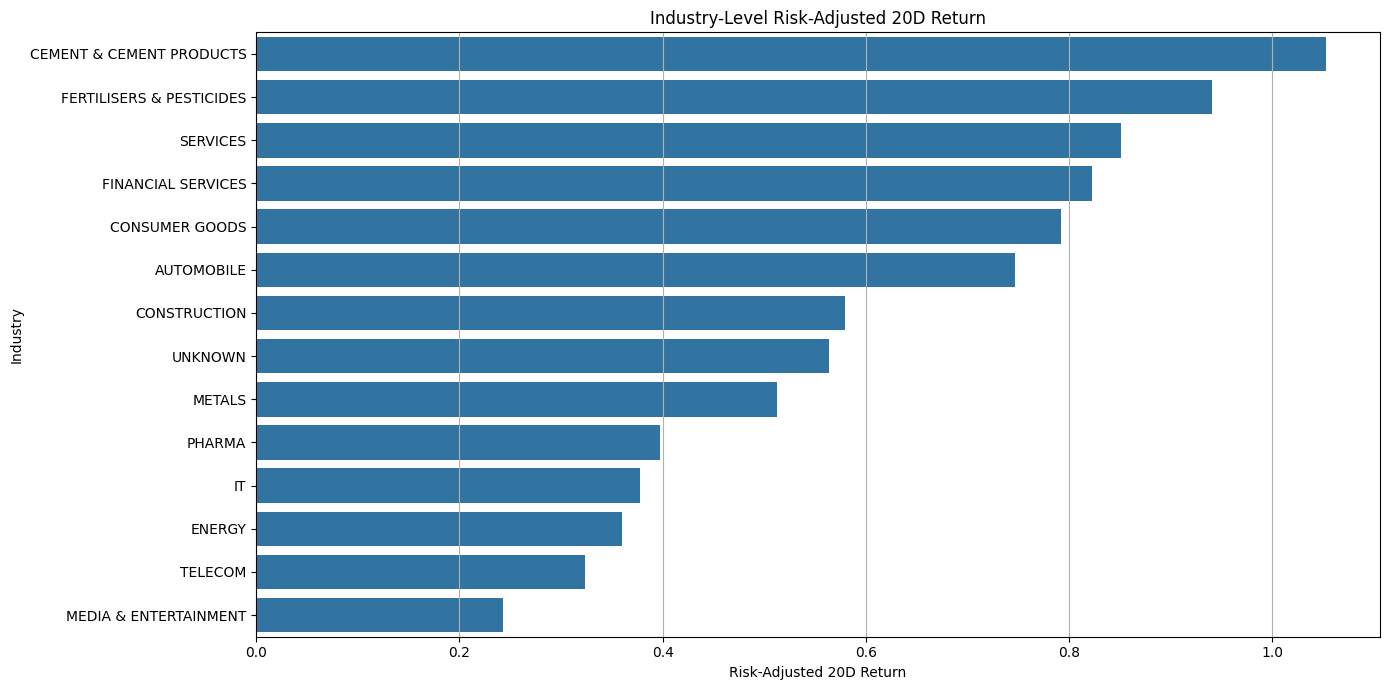

,Industry,Average_Daily_Return,Average_20D_Return,Average_60D_Return,Average_20D_Volatility,Number_of_Records,Number_of_Stocks,Risk_Adjusted_20D_Return
1,CEMENT & CEMENT PRODUCTS,0.001035,0.021976,0.070536,0.020866,14431,3,1.053170
5,FERTILISERS & PESTICIDES,0.001060,0.021395,0.063159,0.022754,1858,1,0.940270
11,SERVICES,0.001008,0.019260,0.057892,0.022636,2299,1,0.850843
6,FINANCIAL SERVICES,0.000955,0.019074,0.057977,0.023188,39911,9,0.822552
3,CONSUMER GOODS,0.000755,0.014863,0.045408,0.018763,27442,6,0.792130
0,AUTOMOBILE,0.000817,0.016800,0.055449,0.022506,24951,6,0.746483
2,CONSTRUCTION,0.000550,0.012380,0.041646,0.021379,4184,1,0.579070
13,UNKNOWN,0.000735,0.015806,0.055016,0.028054,27342,16,0.563429
9,METALS,0.000600,0.012926,0.041999,0.025197,15189,5,0.512987
10,PHARMA,0.000417,0.008183,0.022717,0.020568,15918,3,0.397843


In [19]:
# Industry-level performance after feature creation

industry_performance = df.groupby("Industry").agg(
    Average_Daily_Return=("Return_1D", "mean"),
    Average_20D_Return=("Return_20D", "mean"),
    Average_60D_Return=("Return_60D", "mean"),
    Average_20D_Volatility=("Volatility_20D", "mean"),
    Number_of_Records=("Date", "count"),
    Number_of_Stocks=("Symbol", "nunique")
).reset_index()

industry_performance["Risk_Adjusted_20D_Return"] = (
    industry_performance["Average_20D_Return"] / industry_performance["Average_20D_Volatility"]
)

industry_performance = industry_performance.sort_values(
    "Risk_Adjusted_20D_Return",
    ascending=False
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=industry_performance,
    x="Risk_Adjusted_20D_Return",
    y="Industry"
)
plt.title("Industry-Level Risk-Adjusted 20D Return")
plt.xlabel("Risk-Adjusted 20D Return")
plt.ylabel("Industry")
plt.tight_layout()

chart_path = os.path.join(CHART_DIR, "industry_risk_adjusted_return.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

display(industry_performance)

## 7. Target Creation

The notebook creates multiple targets to satisfy the Stock Predictor Engine requirement:

1. `Future_Return_30D`  
   Future 30-trading-day return.

2. `Future_Direction_30D`  
   Whether future return is positive.

3. `Top_Quartile_Outperformer_30D`  
   Whether the stock belongs to the top 25% performers on a given date.

4. `Future_Return_Relevance`  
   Relevance score for ranking models.

In [20]:
# Future prediction and investment ranking targets

PREDICTION_HORIZON = 30

df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# Future close price after 30 trading days
df["Future_Close_30D"] = df.groupby("Symbol")["Close"].shift(-PREDICTION_HORIZON)

# Future 30-day return
df["Future_Return_30D"] = (df["Future_Close_30D"] / df["Close"]) - 1

# Direction target
df["Future_Direction_30D"] = (df["Future_Return_30D"] > 0).astype(int)

# Cross-sectional future return percentile rank for each date
df["Future_Return_30D_Rank"] = df.groupby("Date")["Future_Return_30D"].rank(pct=True)

# Top quartile outperformer target
df["Top_Quartile_Outperformer_30D"] = (df["Future_Return_30D_Rank"] >= 0.75).astype(int)

# Relevance score based on future return percentile rank
df["Future_Return_Relevance"] = pd.cut(
    df["Future_Return_30D_Rank"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True
)

print("Target creation completed.")
print("Shape:", df.shape)

print("\nFuture return summary:")
display(df["Future_Return_30D"].describe())

print("\nDirection target distribution:")
display(df["Future_Direction_30D"].value_counts(normalize=True))

print("\nTop quartile outperformer target distribution:")
display(df["Top_Quartile_Outperformer_30D"].value_counts(normalize=True))

print("\nRelevance distribution:")
display(df["Future_Return_Relevance"].value_counts().sort_index())

display(df[[
    "Date", "Symbol", "Close", "Future_Close_30D",
    "Future_Return_30D", "Future_Direction_30D",
    "Future_Return_30D_Rank", "Top_Quartile_Outperformer_30D",
    "Future_Return_Relevance"
]].dropna().head(20))

Target creation completed.
Shape: (235192, 79)

Future return summary:


,Future_Return_30D
count,233242.000000
mean,0.021067
std,0.155124
min,-0.968900
25%,-0.053940
50%,0.019487
75%,0.096901
max,2.553935



Direction target distribution:


,proportion
Future_Direction_30D,
1,0.565393
0,0.434607



Top quartile outperformer target distribution:


,proportion
Top_Quartile_Outperformer_30D,
0,0.737687
1,0.262313



Relevance distribution:


,count
Future_Return_Relevance,
0,43763
1,47006
2,47274
3,47006
4,48193


,Date,Symbol,Close,Future_Close_30D,Future_Return_30D,Future_Direction_30D,Future_Return_30D_Rank,Top_Quartile_Outperformer_30D,Future_Return_Relevance
0,2012-01-17,ADANIPORTS,140.00,146.85,0.048929,1,0.326531,0,1
1,2012-01-18,ADANIPORTS,141.70,147.35,0.039873,1,0.265306,0,1
2,2012-01-19,ADANIPORTS,149.40,146.15,-0.021754,0,0.142857,0,0
3,2012-01-20,ADANIPORTS,155.40,143.20,-0.078507,0,0.020408,0,0
4,2012-01-23,ADANIPORTS,146.75,143.55,-0.021806,0,0.183673,0,0
5,2012-01-24,ADANIPORTS,150.05,145.25,-0.031989,0,0.142857,0,0
6,2012-01-25,ADANIPORTS,143.20,135.00,-0.057263,0,0.040816,0,0
7,2012-01-27,ADANIPORTS,147.10,129.90,-0.116927,0,0.040816,0,0
8,2012-01-30,ADANIPORTS,138.40,131.10,-0.052746,0,0.061224,0,0
9,2012-01-31,ADANIPORTS,146.25,135.75,-0.071795,0,0.081633,0,0


## 8. Final Model Dataset Preparation

This section encodes categorical columns, adds date features, selects final features, and removes missing values caused by rolling indicators and future targets.

In [21]:
# Prepare final model dataset

symbol_encoder = LabelEncoder()
industry_encoder = LabelEncoder()

df["Symbol_Encoded"] = symbol_encoder.fit_transform(df["Symbol"])
df["Industry_Encoded"] = industry_encoder.fit_transform(df["Industry"])

# Date-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["DayOfWeek"] = df["Date"].dt.dayofweek

feature_columns = [
    # Raw price-volume features
    "Open", "High", "Low", "Close", "VWAP", "Volume", "Turnover",

    # Return features
    "Return_1D", "Return_5D", "Return_10D", "Return_20D", "Return_60D",
    "Log_Return_1D",

    # Price-action features
    "High_Low_Range", "Open_Close_Change", "Close_vs_VWAP",
    "Volume_Change_1D", "Volume_Change_5D", "Turnover_Change_1D",

    # Moving average features
    "Close_vs_MA_5", "Close_vs_MA_20", "Close_vs_MA_50", "Close_vs_MA_200",

    # EMA / MACD
    "EMA_12", "EMA_26", "MACD", "MACD_Signal", "MACD_Hist",

    # Bollinger Bands
    "BB_Width", "BB_Position",

    # RSI
    "RSI_14",

    # Volatility and momentum
    "Volatility_5D", "Volatility_10D", "Volatility_20D", "Volatility_60D",
    "Momentum_5D", "Momentum_20D", "Momentum_60D",

    # Cross-sectional market features
    "Return_20D_Rank", "Return_60D_Rank",
    "Volatility_20D_Rank", "Momentum_20D_Rank", "RSI_14_Rank",
    "Return_1D_vs_Market", "Return_20D_vs_Market", "Volatility_20D_vs_Market",
    "Return_20D_vs_Industry", "Volatility_20D_vs_Industry",

    # Encoded identity features
    "Symbol_Encoded", "Industry_Encoded",

    # Time features
    "Year", "Month", "Quarter", "DayOfWeek"
]

target_columns = [
    "Future_Return_30D",
    "Future_Direction_30D",
    "Top_Quartile_Outperformer_30D",
    "Future_Return_30D_Rank",
    "Future_Return_Relevance"
]

model_df = df[
    ["Date", "Symbol", "Company Name", "Industry"] + feature_columns + target_columns
].copy()

# Convert relevance to numeric
model_df["Future_Return_Relevance"] = model_df["Future_Return_Relevance"].astype(float)

# Remove infinite and missing values
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna().reset_index(drop=True)

model_df["Future_Return_Relevance"] = model_df["Future_Return_Relevance"].astype(int)

print("Final model dataset shape:", model_df.shape)
print("Number of features:", len(feature_columns))
print("Missing values left:", model_df.isnull().sum().sum())

print("\nDate range in final model dataset:")
print(model_df["Date"].min(), "to", model_df["Date"].max())

display(model_df.head())

Final model dataset shape: (220413, 63)
Number of features: 54
Missing values left: 0

Date range in final model dataset:
2000-10-19 00:00:00 to 2021-03-15 00:00:00


,Date,Symbol,Company Name,Industry,Open,High,Low,Close,VWAP,Volume,Turnover,Return_1D,Return_5D,Return_10D,Return_20D,Return_60D,Log_Return_1D,High_Low_Range,Open_Close_Change,Close_vs_VWAP,Volume_Change_1D,Volume_Change_5D,Turnover_Change_1D,Close_vs_MA_5,Close_vs_MA_20,Close_vs_MA_50,Close_vs_MA_200,EMA_12,EMA_26,MACD,MACD_Signal,MACD_Hist,BB_Width,BB_Position,RSI_14,Volatility_5D,Volatility_10D,Volatility_20D,Volatility_60D,Momentum_5D,Momentum_20D,Momentum_60D,Return_20D_Rank,Return_60D_Rank,Volatility_20D_Rank,Momentum_20D_Rank,RSI_14_Rank,Return_1D_vs_Market,Return_20D_vs_Market,Volatility_20D_vs_Market,Return_20D_vs_Industry,Volatility_20D_vs_Industry,Symbol_Encoded,Industry_Encoded,Year,Month,Quarter,DayOfWeek,Future_Return_30D,Future_Direction_30D,Top_Quartile_Outperformer_30D,Future_Return_30D_Rank,Future_Return_Relevance
0,2012-11-01,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,125.5,126.45,124.00,125.00,125.05,754150,9.430984e+12,-0.017682,-0.043611,0.041667,-0.034749,0.028383,-0.017840,0.019600,-0.003984,-0.000400,-0.553841,-0.490268,-0.561914,-0.005964,-0.001876,0.046603,-0.007361,125.711250,124.095634,1.615616,1.881884,-0.266267,0.100263,0.481284,51.111111,0.019108,0.024596,0.022163,0.021926,-0.043611,-0.034749,0.028383,0.265306,0.306122,0.938776,0.265306,0.612245,-0.026645,-0.029227,0.007833,0.0,0.0,0,11,2012,11,4,3,0.146000,1,1,0.959184,4
1,2012-11-02,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,125.6,128.65,125.60,127.95,127.45,1501687,1.913939e+13,0.023600,0.007480,0.026063,-0.012731,0.031439,0.023326,0.023837,0.018710,0.003923,0.991231,-0.203531,1.029416,0.015960,0.022353,0.069262,0.016551,126.055673,124.381142,1.674531,1.840413,-0.165882,0.097111,0.730178,53.823088,0.019897,0.022556,0.022864,0.021976,0.007480,-0.012731,0.031439,0.428571,0.326531,0.959184,0.428571,0.591837,0.015007,-0.009159,0.008717,0.0,0.0,0,11,2012,11,4,4,0.114889,1,1,0.918367,4
2,2012-11-05,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,127.0,130.60,127.00,127.45,128.88,1196272,1.541736e+13,-0.003908,0.023695,0.024930,-0.005462,0.038289,-0.003915,0.028246,0.003543,-0.011096,-0.203381,-0.244895,-0.194470,0.007271,0.018642,0.062128,0.013152,126.270185,124.608465,1.661720,1.804674,-0.142955,0.096099,0.693992,56.269592,0.016655,0.022589,0.022741,0.021935,0.023695,-0.005462,0.038289,0.448980,0.306122,0.959184,0.448980,0.530612,-0.004418,-0.008568,0.008963,0.0,0.0,0,11,2012,11,4,0,0.139663,1,1,0.918367,4
3,2012-11-06,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,127.4,136.70,126.15,134.85,132.54,3019713,4.002371e+13,0.058062,0.078800,0.039306,0.089257,0.084875,0.056439,0.078235,0.058477,0.017429,1.524270,3.448317,1.596016,0.049416,0.073048,0.119533,0.072598,127.590157,125.367097,2.223059,1.888351,0.334708,0.117417,1.122130,70.612813,0.028987,0.025772,0.024738,0.023102,0.078800,0.089257,0.084875,0.918367,0.510204,0.979592,0.918367,0.836735,0.052247,0.070633,0.011195,0.0,0.0,0,11,2012,11,4,1,0.038191,1,0,0.448980,2
4,2012-11-07,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,135.0,136.00,129.05,130.85,132.90,1782253,2.368567e+13,-0.029663,0.028291,0.017892,0.066857,0.030315,-0.030111,0.053114,-0.030741,-0.015425,-0.409794,0.054390,-0.408209,0.012614,0.037833,0.082219,0.041799,128.091671,125.773238,2.318433,1.974368,0.344065,0.120239,0.814650,63.613551,0.035182,0.027689,0.025738,0.023295,0.028291,0.066857,0.030315,0.836735,0.285714,0.979592,0.836735,0.653061,-0.034374,0.047972,0.012360,0.0,0.0,0,11,2012,11,4,2,0.036683,1,0,0.632653,3


## 9. Time-Based Train / Validation / Test Split

A random split is not appropriate for market time-series data.  
We use time-based splitting:

- Training: 2000 to 2017
- Validation: 2018 to 2019
- Testing: 2020 to 2021

In [22]:
# Time-based train / validation / test split

model_df = model_df.sort_values("Date").reset_index(drop=True)

train_end_date = "2017-12-31"
val_end_date = "2019-12-31"

train_df = model_df[model_df["Date"] <= train_end_date].copy()
val_df = model_df[
    (model_df["Date"] > train_end_date) &
    (model_df["Date"] <= val_end_date)
].copy()
test_df = model_df[model_df["Date"] > val_end_date].copy()

X_train = train_df[feature_columns]
X_val = val_df[feature_columns]
X_test = test_df[feature_columns]

y_train_return = train_df["Future_Return_30D"]
y_val_return = val_df["Future_Return_30D"]
y_test_return = test_df["Future_Return_30D"]

y_train_direction = train_df["Future_Direction_30D"]
y_val_direction = val_df["Future_Direction_30D"]
y_test_direction = test_df["Future_Direction_30D"]

y_train_topq = train_df["Top_Quartile_Outperformer_30D"]
y_val_topq = val_df["Top_Quartile_Outperformer_30D"]
y_test_topq = test_df["Top_Quartile_Outperformer_30D"]

y_train_rank = train_df["Future_Return_Relevance"]
y_val_rank = val_df["Future_Return_Relevance"]
y_test_rank = test_df["Future_Return_Relevance"]

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain date range:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Validation date range:", val_df["Date"].min(), "to", val_df["Date"].max())
print("Test date range:", test_df["Date"].min(), "to", test_df["Date"].max())

print("\nTop quartile target distribution:")
print("Train:")
display(y_train_topq.value_counts(normalize=True))
print("Validation:")
display(y_val_topq.value_counts(normalize=True))
print("Test:")
display(y_test_topq.value_counts(normalize=True))

Train shape: (181556, 63)
Validation shape: (24059, 63)
Test shape: (14798, 63)

Train date range: 2000-10-19 00:00:00 to 2017-12-29 00:00:00
Validation date range: 2018-01-01 00:00:00 to 2019-12-31 00:00:00
Test date range: 2020-01-01 00:00:00 to 2021-03-15 00:00:00

Top quartile target distribution:
Train:


,proportion
Top_Quartile_Outperformer_30D,
0,0.737018
1,0.262982


Validation:


,proportion
Top_Quartile_Outperformer_30D,
0,0.734694
1,0.265306


Test:


,proportion
Top_Quartile_Outperformer_30D,
0,0.734694
1,0.265306


## 10. Baseline Predictor Models

Baseline models are included for transparency and to show why the final system uses ranking-based investment intelligence instead of simple exact return prediction.

Models:
- Linear Regression for future return.
- Ridge Regression for future return.
- Scaled Logistic Regression for direction.

The final submission focuses on ranking and portfolio performance because investment decisions require selecting the best stocks relative to other stocks.

In [23]:
# Baseline regression models

baseline_results = []

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_return)
val_pred_lr = lr_model.predict(X_val)

baseline_results.append({
    "Model": "Linear Regression",
    "Task": "30D return regression",
    "MAE": mean_absolute_error(y_val_return, val_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_val_return, val_pred_lr)),
    "R2": r2_score(y_val_return, val_pred_lr),
    "Directional_Accuracy": accuracy_score((y_val_return > 0).astype(int), (val_pred_lr > 0).astype(int))
})

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train_return)
val_pred_ridge = ridge_model.predict(X_val)

baseline_results.append({
    "Model": "Ridge Regression",
    "Task": "30D return regression",
    "MAE": mean_absolute_error(y_val_return, val_pred_ridge),
    "RMSE": np.sqrt(mean_squared_error(y_val_return, val_pred_ridge)),
    "R2": r2_score(y_val_return, val_pred_ridge),
    "Directional_Accuracy": accuracy_score((y_val_return > 0).astype(int), (val_pred_ridge > 0).astype(int))
})

# Logistic Regression for direction
logistic_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

logistic_scaled.fit(X_train, y_train_direction)
val_pred_logistic = logistic_scaled.predict(X_val)

baseline_results.append({
    "Model": "Scaled Logistic Regression",
    "Task": "30D direction classification",
    "MAE": np.nan,
    "RMSE": np.nan,
    "R2": np.nan,
    "Directional_Accuracy": accuracy_score(y_val_direction, val_pred_logistic)
})

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)

,Model,Task,MAE,RMSE,R2,Directional_Accuracy
0,Linear Regression,30D return regression,0.082329,0.111031,-0.091783,0.487759
1,Ridge Regression,30D return regression,0.083084,0.111093,-0.093007,0.456420
2,Scaled Logistic Regression,30D direction classification,NaN,NaN,NaN,0.473045


## 11. LightGBM Ranker Model

The final predictor engine is a LightGBM Ranker.

Why ranking?

- Investors compare stocks against other available stocks.
- The objective is to select better opportunities, not just predict whether a stock goes up.
- Ranking is directly aligned with portfolio construction.

In [24]:
# Train LightGBM Ranker on training set and validate on validation set

train_group = train_df.groupby("Date").size().values
val_group = val_df.groupby("Date").size().values

ranker_model = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.2,
    random_state=42,
    n_jobs=-1
)

ranker_model.fit(
    X_train,
    y_train_rank,
    group=train_group,
    eval_set=[(X_val, y_val_rank)],
    eval_group=[val_group],
    eval_at=[5, 10],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)
    ]
)

val_rank_scores = ranker_model.predict(X_val)

print("Ranker training completed.")
print("Validation rank score summary:")
display(pd.Series(val_rank_scores).describe())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.269914 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12323
[LightGBM] [Info] Number of data points in the train set: 181556, number of used features: 54
Training until validation scores don't improve for 100 rounds
[50]	valid_0's ndcg@5: 0.367964	valid_0's ndcg@10: 0.366986
[100]	valid_0's ndcg@5: 0.357334	valid_0's ndcg@10: 0.366584
Early stopping, best iteration is:
[1]	valid_0's ndcg@5: 0.421962	valid_0's ndcg@10: 0.397307
Ranker training completed.
Validation rank score summary:


,0
count,24059.000000
mean,-0.001590
std,0.007647
min,-0.020294
25%,-0.005125
50%,-0.004648
75%,0.001581
max,0.028981


In [25]:
# Helper function for portfolio strategy evaluation

def evaluate_strategy(df, score_column, strategy_name, top_k=10):
    temp = df.copy()

    temp["Strategy_Rank"] = temp.groupby("Date")[score_column].rank(
        ascending=False,
        method="first"
    )

    selected = temp[temp["Strategy_Rank"] <= top_k].copy()

    market_daily_return = temp.groupby("Date")["Future_Return_30D"].mean()
    strategy_daily_return = selected.groupby("Date")["Future_Return_30D"].mean()

    comparison = pd.DataFrame({
        "Market_Return": market_daily_return,
        "Strategy_Return": strategy_daily_return
    }).dropna()

    avg_market_return = comparison["Market_Return"].mean()
    avg_strategy_return = comparison["Strategy_Return"].mean()
    excess_return = avg_strategy_return - avg_market_return

    positive_excess_rate = (
        comparison["Strategy_Return"] > comparison["Market_Return"]
    ).mean()

    hit_rate = selected["Top_Quartile_Outperformer_30D"].mean()

    return {
        "Strategy": strategy_name,
        "Top_K": top_k,
        "Average_30D_Return": avg_strategy_return,
        "Market_Average_30D_Return": avg_market_return,
        "Excess_Return_vs_Market": excess_return,
        "Positive_Excess_Return_Rate": positive_excess_rate,
        "Top_Quartile_Hit_Rate": hit_rate
    }

In [26]:
# Evaluate validation ranking performance

val_strategy_df = val_df[[
    "Date", "Symbol", "Company Name", "Industry",
    "Future_Return_30D",
    "Future_Return_30D_Rank",
    "Top_Quartile_Outperformer_30D",
    "Return_20D_Rank",
    "Return_60D_Rank",
    "Volatility_20D_Rank",
    "Momentum_20D_Rank",
    "RSI_14_Rank",
    "Return_20D_vs_Market",
    "Return_20D_vs_Industry",
    "Volatility_20D_vs_Market",
    "Volatility_20D_vs_Industry"
]].copy()

val_strategy_df["Ranker_Score"] = val_rank_scores

val_strategy_df["Ranker_Score_Rank"] = val_strategy_df.groupby("Date")["Ranker_Score"].rank(
    pct=True,
    ascending=True
)

val_ranker_results = [
    evaluate_strategy(val_strategy_df, "Ranker_Score_Rank", "Validation Ranker Score", top_k=5),
    evaluate_strategy(val_strategy_df, "Ranker_Score_Rank", "Validation Ranker Score", top_k=10)
]

val_ranker_results_df = pd.DataFrame(val_ranker_results)
display(val_ranker_results_df)

,Strategy,Top_K,Average_30D_Return,Market_Average_30D_Return,Excess_Return_vs_Market,Positive_Excess_Return_Rate,Top_Quartile_Hit_Rate
0,Validation Ranker Score,5,0.006908,-0.001189,0.008098,0.580448,0.333198
1,Validation Ranker Score,10,0.004504,-0.001189,0.005693,0.590631,0.302648


## 12. Final Ranker Training and Unseen Test Evaluation

After validation, the final ranker is trained on all pre-test data from 2000 to 2019 and tested on unseen 2020 to 2021 data.

In [27]:
# Final training on Train + Validation and evaluation on Test

final_train_df = model_df[model_df["Date"] <= val_end_date].copy()
final_test_df = model_df[model_df["Date"] > val_end_date].copy()

X_final_train_rank = final_train_df[feature_columns]
y_final_train_rank = final_train_df["Future_Return_Relevance"]

X_final_test_rank = final_test_df[feature_columns]
y_final_test_rank = final_test_df["Future_Return_Relevance"]

final_train_group = final_train_df.groupby("Date").size().values

print("Final train rows:", X_final_train_rank.shape[0])
print("Final test rows:", X_final_test_rank.shape[0])
print("Number of final train groups/dates:", len(final_train_group))

final_ranker_model = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.2,
    random_state=42,
    n_jobs=-1
)

final_ranker_model.fit(
    X_final_train_rank,
    y_final_train_rank,
    group=final_train_group
)

final_test_scores = final_ranker_model.predict(X_final_test_rank)

final_test_strategy_df = final_test_df[[
    "Date", "Symbol", "Company Name", "Industry",
    "Future_Return_30D",
    "Future_Return_30D_Rank",
    "Top_Quartile_Outperformer_30D",
    "Return_20D_Rank",
    "Return_60D_Rank",
    "Volatility_20D_Rank",
    "Momentum_20D_Rank",
    "RSI_14_Rank",
    "Return_20D_vs_Market",
    "Return_20D_vs_Industry",
    "Volatility_20D_vs_Market",
    "Volatility_20D_vs_Industry"
]].copy()

final_test_strategy_df["Final_Ranker_Score"] = final_test_scores

final_test_strategy_df["Final_Ranker_Score_Rank"] = final_test_strategy_df.groupby("Date")["Final_Ranker_Score"].rank(
    pct=True,
    ascending=True
)

final_test_strategy_df["Momentum_Score"] = (
    0.50 * final_test_strategy_df["Return_20D_Rank"] +
    0.50 * final_test_strategy_df["Return_60D_Rank"]
)

final_test_strategy_df["Low_Volatility_Score"] = 1 - final_test_strategy_df["Volatility_20D_Rank"]

final_test_strategy_df["RSI_Balanced_Score"] = 1 - abs(final_test_strategy_df["RSI_14_Rank"] - 0.65)

final_test_results = []
for top_k in [5, 10]:
    final_test_results.append(
        evaluate_strategy(final_test_strategy_df, "Final_Ranker_Score_Rank", "Final Ranker Score", top_k=top_k)
    )

final_test_results_df = pd.DataFrame(final_test_results)
display(final_test_results_df)

Final train rows: 205615
Final test rows: 14798
Number of final train groups/dates: 4775
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.148319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12324
[LightGBM] [Info] Number of data points in the train set: 205615, number of used features: 54


,Strategy,Top_K,Average_30D_Return,Market_Average_30D_Return,Excess_Return_vs_Market,Positive_Excess_Return_Rate,Top_Quartile_Hit_Rate
0,Final Ranker Score,5,0.064894,0.033486,0.031408,0.615894,0.341060
1,Final Ranker Score,10,0.057632,0.033486,0.024146,0.705298,0.327152


## 13. Portfolio Construction Module

Three investor-profile portfolios are constructed:

1. **Conservative Investor Portfolio**  
   Lower risk and drawdown control.

2. **Balanced Investor Portfolio**  
   Best risk-adjusted objective.

3. **Aggressive Investor Portfolio**  
   Highest return potential.

All portfolios use equal-weight allocations.

In [28]:
# Final investor-profile portfolio scoring

final_portfolio_df = final_test_strategy_df.copy()

# Conservative: model score + lower volatility
final_portfolio_df["Final_Conservative_Score"] = (
    0.50 * final_portfolio_df["Final_Ranker_Score_Rank"] +
    0.50 * (1 - final_portfolio_df["Volatility_20D_Rank"])
)

# Balanced: stronger model score with some risk control
final_portfolio_df["Final_Balanced_Score"] = (
    0.70 * final_portfolio_df["Final_Ranker_Score_Rank"] +
    0.30 * (1 - final_portfolio_df["Volatility_20D_Rank"])
)

# Aggressive: pure model ranking
final_portfolio_df["Final_Aggressive_Score"] = final_portfolio_df["Final_Ranker_Score_Rank"]

final_profile_scores = {
    "Conservative Investor Portfolio": "Final_Conservative_Score",
    "Balanced Investor Portfolio": "Final_Balanced_Score",
    "Aggressive Investor Portfolio": "Final_Aggressive_Score"
}

final_profile_results = []

for profile_name, score_col in final_profile_scores.items():
    final_profile_results.append(evaluate_strategy(final_portfolio_df, score_col, profile_name, top_k=5))
    final_profile_results.append(evaluate_strategy(final_portfolio_df, score_col, profile_name, top_k=10))

final_profile_results_df = pd.DataFrame(final_profile_results)

final_profile_results_df = final_profile_results_df.sort_values(
    ["Excess_Return_vs_Market", "Positive_Excess_Return_Rate"],
    ascending=False
).reset_index(drop=True)

display(final_profile_results_df)

,Strategy,Top_K,Average_30D_Return,Market_Average_30D_Return,Excess_Return_vs_Market,Positive_Excess_Return_Rate,Top_Quartile_Hit_Rate
0,Aggressive Investor Portfolio,5,0.064894,0.033486,0.031408,0.615894,0.341060
1,Aggressive Investor Portfolio,10,0.057632,0.033486,0.024146,0.705298,0.327152
2,Balanced Investor Portfolio,10,0.051082,0.033486,0.017596,0.649007,0.322185
3,Conservative Investor Portfolio,10,0.036670,0.033486,0.003183,0.556291,0.278808
4,Conservative Investor Portfolio,5,0.034199,0.033486,0.000713,0.493377,0.250993
5,Balanced Investor Portfolio,5,0.033985,0.033486,0.000499,0.463576,0.266887


In [29]:
# Helper to get selected portfolio returns

def get_profile_returns(df, score_column, top_k):
    temp = df.copy()

    temp["Profile_Rank"] = temp.groupby("Date")[score_column].rank(
        ascending=False,
        method="first"
    )

    selected = temp[temp["Profile_Rank"] <= top_k].copy()

    market_returns = temp.groupby("Date")["Future_Return_30D"].mean()
    profile_returns = selected.groupby("Date")["Future_Return_30D"].mean()

    returns_df = pd.DataFrame({
        "Market_Return": market_returns,
        "Portfolio_Return": profile_returns
    }).dropna()

    return returns_df, selected


# Final chosen profile settings
conservative_returns_df, conservative_selected = get_profile_returns(
    final_portfolio_df,
    score_column="Final_Conservative_Score",
    top_k=10
)

balanced_returns_df, balanced_selected = get_profile_returns(
    final_portfolio_df,
    score_column="Final_Balanced_Score",
    top_k=10
)

aggressive_returns_df, aggressive_selected = get_profile_returns(
    final_portfolio_df,
    score_column="Final_Aggressive_Score",
    top_k=5
)

# Add profile labels
conservative_selected["Investor_Profile"] = "Conservative"
balanced_selected["Investor_Profile"] = "Balanced"
aggressive_selected["Investor_Profile"] = "Aggressive"

# Add equal-weight allocation
conservative_selected["Allocation"] = conservative_selected.groupby("Date")["Symbol"].transform(lambda x: 1 / len(x))
balanced_selected["Allocation"] = balanced_selected.groupby("Date")["Symbol"].transform(lambda x: 1 / len(x))
aggressive_selected["Allocation"] = aggressive_selected.groupby("Date")["Symbol"].transform(lambda x: 1 / len(x))

print("Allocation checks:")
print("Conservative allocation sum:")
display(conservative_selected.groupby("Date")["Allocation"].sum().head())
print("Balanced allocation sum:")
display(balanced_selected.groupby("Date")["Allocation"].sum().head())
print("Aggressive allocation sum:")
display(aggressive_selected.groupby("Date")["Allocation"].sum().head())

display(aggressive_selected[[
    "Date", "Symbol", "Company Name", "Industry", "Allocation", "Future_Return_30D"
]].head(10))

Allocation checks:
Conservative allocation sum:


,Allocation
Date,
2020-01-01,1.0
2020-01-02,1.0
2020-01-03,1.0
2020-01-06,1.0
2020-01-07,1.0


Balanced allocation sum:


,Allocation
Date,
2020-01-01,1.0
2020-01-02,1.0
2020-01-03,1.0
2020-01-06,1.0
2020-01-07,1.0


Aggressive allocation sum:


,Allocation
Date,
2020-01-01,1.0
2020-01-02,1.0
2020-01-03,1.0
2020-01-06,1.0
2020-01-07,1.0


,Date,Symbol,Company Name,Industry,Allocation,Future_Return_30D
205618,2020-01-01,BRITANNIA,Britannia Industries Ltd.,CONSUMER GOODS,0.2,0.031270
205632,2020-01-01,BAJAJFINSV,Bajaj Finserv Ltd.,FINANCIAL SERVICES,0.2,0.037655
205636,2020-01-01,HINDUNILVR,Hindustan Unilever Ltd.,CONSUMER GOODS,0.2,0.111590
205648,2020-01-01,NESTLEIND,Nestle India Ltd.,CONSUMER GOODS,0.2,0.082421
205658,2020-01-01,BAJFINANCE,Bajaj Finance Ltd.,FINANCIAL SERVICES,0.2,0.122433
205665,2020-01-02,BRITANNIA,Britannia Industries Ltd.,CONSUMER GOODS,0.2,0.027314
205672,2020-01-02,NESTLEIND,Nestle India Ltd.,CONSUMER GOODS,0.2,0.106478
205695,2020-01-02,BAJFINANCE,Bajaj Finance Ltd.,FINANCIAL SERVICES,0.2,0.123091
205698,2020-01-02,BAJAJFINSV,Bajaj Finserv Ltd.,FINANCIAL SERVICES,0.2,0.028010
205703,2020-01-02,HINDUNILVR,Hindustan Unilever Ltd.,CONSUMER GOODS,0.2,0.166301


## 14. Risk Assessment Module

The risk module evaluates:

- Average 30-day return
- 30-day volatility
- Annualized return
- Annualized volatility
- Sharpe ratio
- Sortino ratio
- Negative return rate
- Non-overlapping 30-day maximum drawdown

In [30]:
# Risk metrics

def calculate_strategy_risk_metrics(returns, annualization_factor=12):
    avg_30d_return = returns.mean()
    volatility_30d = returns.std()

    annualized_return = avg_30d_return * annualization_factor
    annualized_volatility = volatility_30d * np.sqrt(annualization_factor)

    sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility != 0 else np.nan

    downside_returns = returns[returns < 0]
    downside_volatility = downside_returns.std() * np.sqrt(annualization_factor)
    sortino_ratio = annualized_return / downside_volatility if downside_volatility != 0 else np.nan

    negative_return_rate = (returns < 0).mean()

    return {
        "Average_30D_Return": avg_30d_return,
        "30D_Volatility": volatility_30d,
        "Annualized_Return": annualized_return,
        "Annualized_Volatility": annualized_volatility,
        "Sharpe_Ratio": sharpe_ratio,
        "Sortino_Ratio": sortino_ratio,
        "Negative_Return_Rate": negative_return_rate
    }


def calculate_max_drawdown_from_returns(returns):
    cumulative = (1 + returns).cumprod()
    rolling_peak = cumulative.cummax()
    drawdown = (cumulative - rolling_peak) / rolling_peak
    return drawdown.min()


def get_non_overlapping_returns(returns_df, return_column, step=30):
    temp = returns_df.copy().reset_index()
    temp = temp.sort_values("Date").reset_index(drop=True)
    return temp.iloc[::step][return_column]


market_profile_risk = calculate_strategy_risk_metrics(conservative_returns_df["Market_Return"])
conservative_risk = calculate_strategy_risk_metrics(conservative_returns_df["Portfolio_Return"])
balanced_risk = calculate_strategy_risk_metrics(balanced_returns_df["Portfolio_Return"])
aggressive_risk = calculate_strategy_risk_metrics(aggressive_returns_df["Portfolio_Return"])

final_profile_risk_summary = pd.DataFrame([
    {"Portfolio": "Market Average", **market_profile_risk},
    {"Portfolio": "Conservative Investor Portfolio", **conservative_risk},
    {"Portfolio": "Balanced Investor Portfolio", **balanced_risk},
    {"Portfolio": "Aggressive Investor Portfolio", **aggressive_risk}
])

# Correct non-overlapping max drawdown
market_non_overlap = get_non_overlapping_returns(conservative_returns_df, "Market_Return", step=30)
conservative_non_overlap = get_non_overlapping_returns(conservative_returns_df, "Portfolio_Return", step=30)
balanced_non_overlap = get_non_overlapping_returns(balanced_returns_df, "Portfolio_Return", step=30)
aggressive_non_overlap = get_non_overlapping_returns(aggressive_returns_df, "Portfolio_Return", step=30)

final_profile_risk_summary["Max_Drawdown_Non_Overlapping_30D"] = [
    calculate_max_drawdown_from_returns(market_non_overlap),
    calculate_max_drawdown_from_returns(conservative_non_overlap),
    calculate_max_drawdown_from_returns(balanced_non_overlap),
    calculate_max_drawdown_from_returns(aggressive_non_overlap)
]

display(final_profile_risk_summary)

,Portfolio,Average_30D_Return,30D_Volatility,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Sortino_Ratio,Negative_Return_Rate,Max_Drawdown_Non_Overlapping_30D
0,Market Average,0.033486,0.119513,0.401836,0.414005,0.970607,0.992719,0.288079,-0.315684
1,Conservative Investor Portfolio,0.036670,0.114069,0.440037,0.395147,1.113604,1.272290,0.274834,-0.200231
2,Balanced Investor Portfolio,0.051082,0.130331,0.612984,0.451481,1.357719,1.504939,0.238411,-0.232668
3,Aggressive Investor Portfolio,0.064894,0.184170,0.778730,0.637983,1.220613,1.470015,0.314570,-0.368596


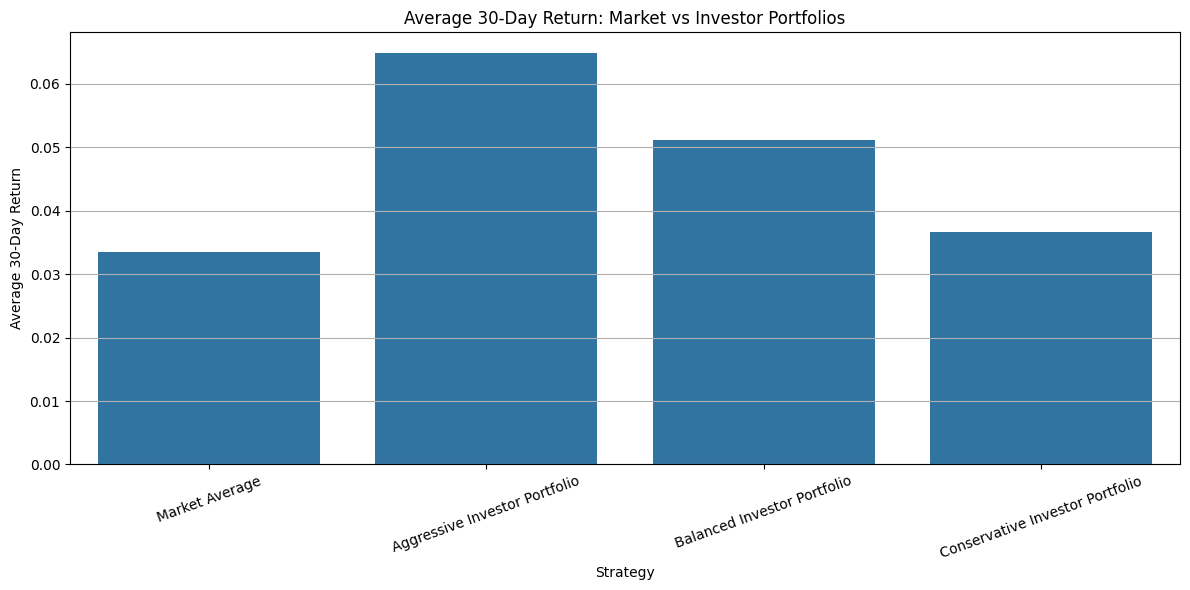

,Strategy,Top_K,Average_30D_Return,Market_Average_30D_Return,Excess_Return_vs_Market,Positive_Excess_Return_Rate,Top_Quartile_Hit_Rate
0,Market Average,0,0.033486,0.033486,0.000000,NaN,NaN
1,Aggressive Investor Portfolio,5,0.064894,0.033486,0.031408,0.615894,0.341060
2,Balanced Investor Portfolio,10,0.051082,0.033486,0.017596,0.649007,0.322185
3,Conservative Investor Portfolio,10,0.036670,0.033486,0.003183,0.556291,0.278808


In [31]:
# Portfolio return comparison chart

portfolio_return_plot = final_profile_results_df.copy()

portfolio_return_plot = portfolio_return_plot[
    (
        (portfolio_return_plot["Strategy"] == "Conservative Investor Portfolio") &
        (portfolio_return_plot["Top_K"] == 10)
    ) |
    (
        (portfolio_return_plot["Strategy"] == "Balanced Investor Portfolio") &
        (portfolio_return_plot["Top_K"] == 10)
    ) |
    (
        (portfolio_return_plot["Strategy"] == "Aggressive Investor Portfolio") &
        (portfolio_return_plot["Top_K"] == 5)
    )
].copy()

market_row = pd.DataFrame([{
    "Strategy": "Market Average",
    "Top_K": 0,
    "Average_30D_Return": portfolio_return_plot["Market_Average_30D_Return"].iloc[0],
    "Market_Average_30D_Return": portfolio_return_plot["Market_Average_30D_Return"].iloc[0],
    "Excess_Return_vs_Market": 0,
    "Positive_Excess_Return_Rate": np.nan,
    "Top_Quartile_Hit_Rate": np.nan
}])

portfolio_return_plot = pd.concat([market_row, portfolio_return_plot], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=portfolio_return_plot,
    x="Strategy",
    y="Average_30D_Return"
)
plt.title("Average 30-Day Return: Market vs Investor Portfolios")
plt.xlabel("Strategy")
plt.ylabel("Average 30-Day Return")
plt.xticks(rotation=20)
plt.tight_layout()

chart_path = os.path.join(CHART_DIR, "portfolio_average_30d_return_comparison.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

display(portfolio_return_plot)

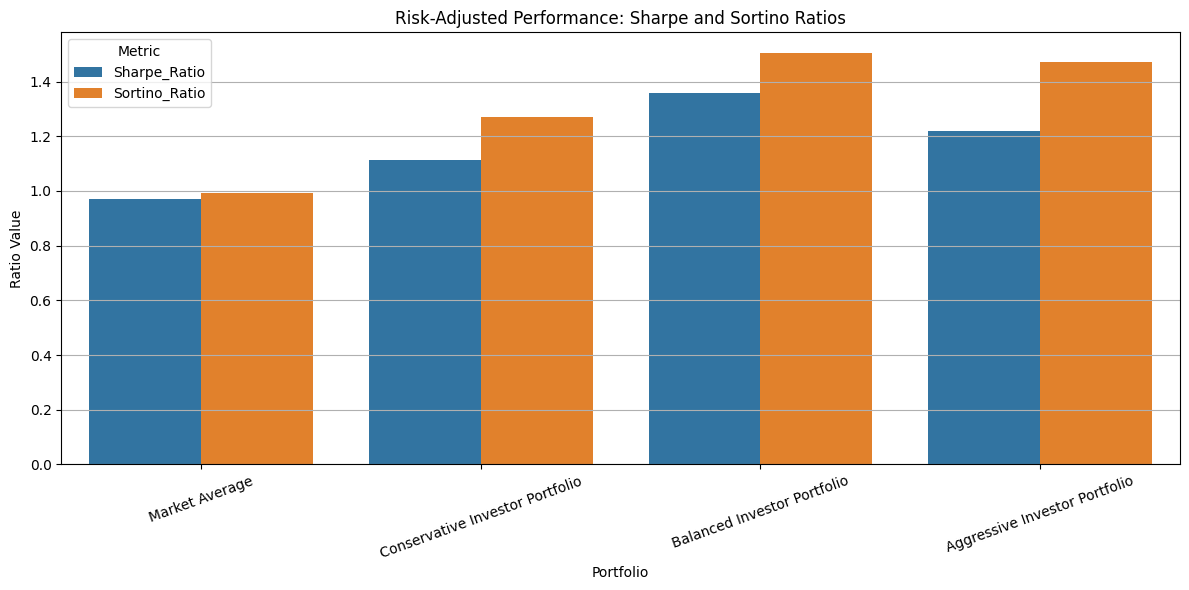

,Portfolio,Average_30D_Return,30D_Volatility,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Sortino_Ratio,Negative_Return_Rate,Max_Drawdown_Non_Overlapping_30D
0,Market Average,0.033486,0.119513,0.401836,0.414005,0.970607,0.992719,0.288079,-0.315684
1,Conservative Investor Portfolio,0.036670,0.114069,0.440037,0.395147,1.113604,1.272290,0.274834,-0.200231
2,Balanced Investor Portfolio,0.051082,0.130331,0.612984,0.451481,1.357719,1.504939,0.238411,-0.232668
3,Aggressive Investor Portfolio,0.064894,0.184170,0.778730,0.637983,1.220613,1.470015,0.314570,-0.368596


In [32]:
# Risk-adjusted performance comparison chart

risk_melted = final_profile_risk_summary.melt(
    id_vars="Portfolio",
    value_vars=["Sharpe_Ratio", "Sortino_Ratio"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=risk_melted,
    x="Portfolio",
    y="Value",
    hue="Metric"
)
plt.title("Risk-Adjusted Performance: Sharpe and Sortino Ratios")
plt.xlabel("Portfolio")
plt.ylabel("Ratio Value")
plt.xticks(rotation=20)
plt.tight_layout()

chart_path = os.path.join(CHART_DIR, "risk_adjusted_performance_comparison.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

display(final_profile_risk_summary)

## 15. Explainable AI Framework

The notebook provides two kinds of explainability:

1. **Model-level explainability** through LightGBM feature importance.
2. **Recommendation-level explainability** through natural-language explanations.

Top 25 most important features used by the final ranker model:


,Feature,Importance
0,Symbol_Encoded,945
1,Volatility_60D,893
2,Close_vs_MA_200,751
3,EMA_26,728
4,Industry_Encoded,483
5,Volatility_20D,368
6,Return_60D_Rank,355
7,Volatility_20D_vs_Industry,331
8,MACD_Signal,315
9,Volatility_20D_vs_Market,307


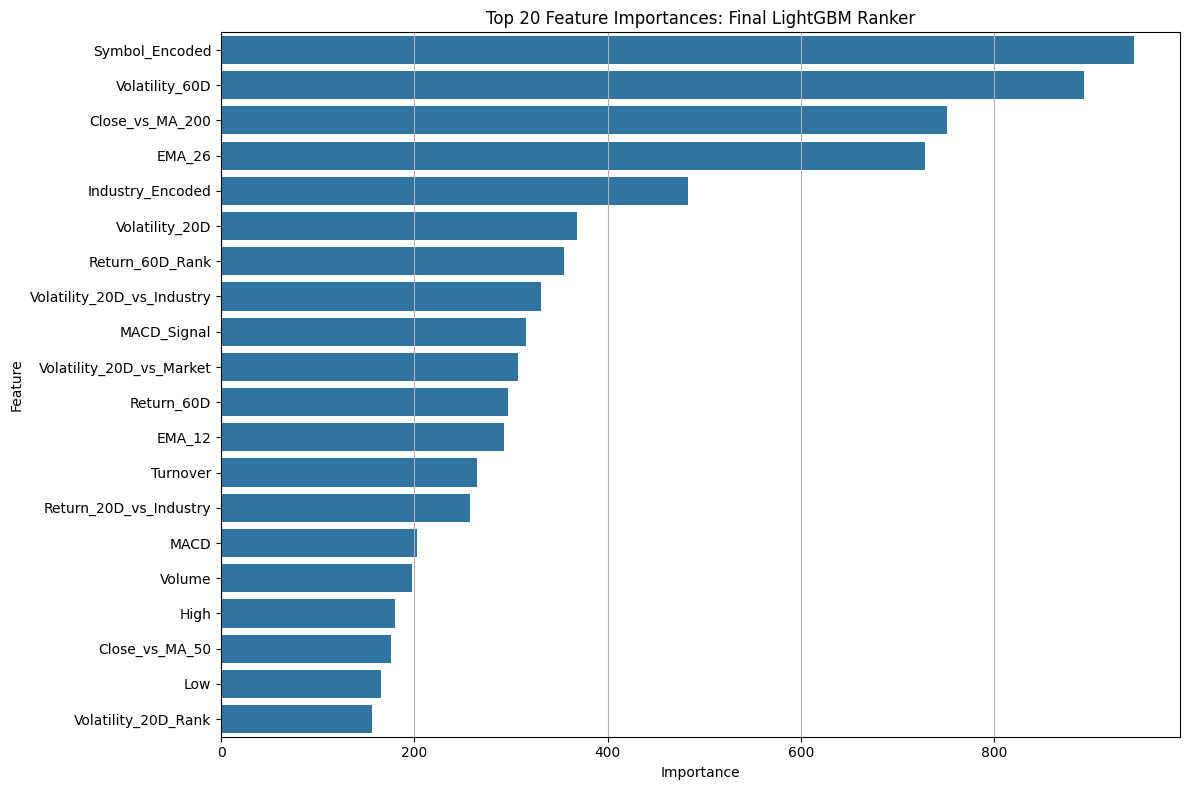

In [33]:
# Feature importance

feature_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": final_ranker_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Top 25 most important features used by the final ranker model:")
display(feature_importance_df.head(25))

# Feature importance chart
top_features_plot = feature_importance_df.head(20).copy()

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_features_plot,
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Feature Importances: Final LightGBM Ranker")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

chart_path = os.path.join(CHART_DIR, "top20_feature_importance.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

In [34]:
# Recommendation explanation engine

def explain_recommendation(row, investor_profile):
    reasons = []

    if row["Final_Ranker_Score_Rank"] >= 0.80:
        reasons.append("high ML ranker score, indicating strong predicted relative performance")
    elif row["Final_Ranker_Score_Rank"] >= 0.60:
        reasons.append("above-average ML ranker score")

    if row["Momentum_Score"] >= 0.75:
        reasons.append("strong recent momentum compared with other stocks")
    elif row["Momentum_Score"] >= 0.55:
        reasons.append("moderate positive momentum")

    low_vol_score = 1 - row["Volatility_20D_Rank"]
    if low_vol_score >= 0.75:
        reasons.append("low recent volatility, supporting better risk control")
    elif low_vol_score >= 0.55:
        reasons.append("moderate volatility profile")

    if 0.35 <= row["RSI_14_Rank"] <= 0.80:
        reasons.append("RSI is in a balanced range, avoiding extreme overbought/oversold conditions")

    reasons.append(f"belongs to the {row['Industry']} sector")

    if investor_profile == "Conservative":
        profile_note = "selected because it balances model confidence with lower volatility"
    elif investor_profile == "Balanced":
        profile_note = "selected because it balances expected outperformance and risk control"
    else:
        profile_note = "selected because it has strong model-ranked return potential"

    return profile_note + "; " + "; ".join(reasons) + "."


conservative_selected["Explanation"] = conservative_selected.apply(
    lambda row: explain_recommendation(row, "Conservative"), axis=1
)

balanced_selected["Explanation"] = balanced_selected.apply(
    lambda row: explain_recommendation(row, "Balanced"), axis=1
)

aggressive_selected["Explanation"] = aggressive_selected.apply(
    lambda row: explain_recommendation(row, "Aggressive"), axis=1
)

sample_explanation_date = aggressive_selected["Date"].min()
sample_explanations = aggressive_selected[
    aggressive_selected["Date"] == sample_explanation_date
].copy()

display(sample_explanations[[
    "Date",
    "Symbol",
    "Company Name",
    "Industry",
    "Investor_Profile",
    "Final_Ranker_Score_Rank",
    "Momentum_Score",
    "Volatility_20D_Rank",
    "Future_Return_30D",
    "Allocation",
    "Explanation"
]])

,Date,Symbol,Company Name,Industry,Investor_Profile,Final_Ranker_Score_Rank,Momentum_Score,Volatility_20D_Rank,Future_Return_30D,Allocation,Explanation
205618,2020-01-01,BRITANNIA,Britannia Industries Ltd.,CONSUMER GOODS,Aggressive,0.938776,0.377551,0.020408,0.031270,0.2,"selected because it has strong model-ranked return potential; high ML ranker score, indicating strong predicted relative performance; low recent volatility, supporting better risk control; belongs to the CONSUMER GOODS sector."
205632,2020-01-01,BAJAJFINSV,Bajaj Finserv Ltd.,FINANCIAL SERVICES,Aggressive,1.000000,0.653061,0.061224,0.037655,0.2,"selected because it has strong model-ranked return potential; high ML ranker score, indicating strong predicted relative performance; moderate positive momentum; low recent volatility, supporting better risk control; belongs to the FINANCIAL SERVICES sector."
205636,2020-01-01,HINDUNILVR,Hindustan Unilever Ltd.,CONSUMER GOODS,Aggressive,0.918367,0.173469,0.102041,0.111590,0.2,"selected because it has strong model-ranked return potential; high ML ranker score, indicating strong predicted relative performance; low recent volatility, supporting better risk control; belongs to the CONSUMER GOODS sector."
205648,2020-01-01,NESTLEIND,Nestle India Ltd.,CONSUMER GOODS,Aggressive,0.959184,0.571429,0.469388,0.082421,0.2,"selected because it has strong model-ranked return potential; high ML ranker score, indicating strong predicted relative performance; moderate positive momentum; RSI is in a balanced range, avoiding extreme overbought/oversold conditions; belongs to the CONSUMER GOODS sector."
205658,2020-01-01,BAJFINANCE,Bajaj Finance Ltd.,FINANCIAL SERVICES,Aggressive,0.979592,0.704082,0.163265,0.122433,0.2,"selected because it has strong model-ranked return potential; high ML ranker score, indicating strong predicted relative performance; moderate positive momentum; low recent volatility, supporting better risk control; RSI is in a balanced range, avoiding extreme overbought/oversold conditions; belongs to the FINANCIAL SERVICES sector."


## 16. Market Anomaly Detection

The anomaly detection module identifies:

1. Unusual volume activity.
2. Volatility spikes.
3. Rolling 60-day extreme drawdowns.

,Anomaly_Type,Total_Records,Percentage_of_Data
0,Unusual Volume,14056,5.976394
1,Volatility Spike,18293,7.777901
2,Rolling 60D Extreme Drawdown,30955,13.161587
3,Any Anomaly,54944,23.361339


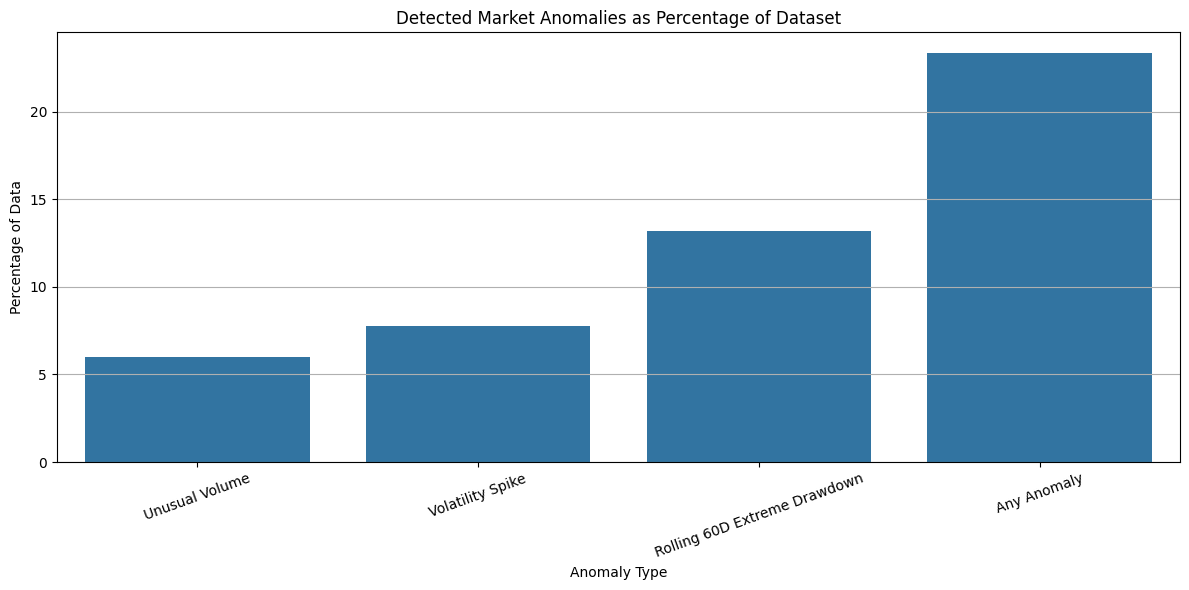

Sample anomaly records:


,Date,Symbol,Company Name,Industry,Close,Return_1D,Volume_ZScore_20,Volatility_ZScore_60,Rolling_60D_Drawdown,Unusual_Volume_Flag,Volatility_Spike_Flag,Rolling_60D_Extreme_Drawdown_Flag
79,2012-05-11,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,121.50,-0.028389,2.576459,-1.077895,-0.204062,True,False,True
80,2012-05-14,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,114.90,-0.054321,1.682915,-0.408255,-0.247298,False,False,True
81,2012-05-15,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,114.70,-0.001741,-0.064447,-0.412054,-0.248608,False,False,True
82,2012-05-16,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,111.00,-0.032258,1.925480,-0.215309,-0.272846,False,False,True
83,2012-05-17,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,113.80,0.025225,1.223563,-0.363836,-0.234443,False,False,True
84,2012-05-18,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,111.70,-0.018453,0.617177,-0.401783,-0.248570,False,False,True
85,2012-05-21,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,112.60,0.008057,0.492443,-0.428805,-0.242516,False,False,True
86,2012-05-22,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,111.75,-0.007549,-1.088119,-0.513606,-0.248234,False,False,True
87,2012-05-23,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,110.25,-0.013423,0.121166,-0.566318,-0.258325,False,False,True
88,2012-05-24,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,112.00,0.015873,-0.053869,-0.775682,-0.246552,False,False,True


In [35]:
# Market anomaly detection

anomaly_df = df.copy()
anomaly_df = anomaly_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# Volume statistics
anomaly_df["Volume_MA_20"] = anomaly_df.groupby("Symbol")["Volume"].transform(
    lambda x: x.rolling(window=20).mean()
)

anomaly_df["Volume_STD_20"] = anomaly_df.groupby("Symbol")["Volume"].transform(
    lambda x: x.rolling(window=20).std()
)

anomaly_df["Volume_ZScore_20"] = (
    anomaly_df["Volume"] - anomaly_df["Volume_MA_20"]
) / anomaly_df["Volume_STD_20"]

# Volatility spike statistics
anomaly_df["Volatility_MA_60"] = anomaly_df.groupby("Symbol")["Volatility_20D"].transform(
    lambda x: x.rolling(window=60).mean()
)

anomaly_df["Volatility_STD_60"] = anomaly_df.groupby("Symbol")["Volatility_20D"].transform(
    lambda x: x.rolling(window=60).std()
)

anomaly_df["Volatility_ZScore_60"] = (
    anomaly_df["Volatility_20D"] - anomaly_df["Volatility_MA_60"]
) / anomaly_df["Volatility_STD_60"]

# Rolling 60-day drawdown
anomaly_df["Rolling_60D_Peak_Close"] = anomaly_df.groupby("Symbol")["Close"].transform(
    lambda x: x.rolling(window=60).max()
)

anomaly_df["Rolling_60D_Drawdown"] = (
    anomaly_df["Close"] - anomaly_df["Rolling_60D_Peak_Close"]
) / anomaly_df["Rolling_60D_Peak_Close"]

# Flags
anomaly_df["Unusual_Volume_Flag"] = anomaly_df["Volume_ZScore_20"] > 2
anomaly_df["Volatility_Spike_Flag"] = anomaly_df["Volatility_ZScore_60"] > 2
anomaly_df["Rolling_60D_Extreme_Drawdown_Flag"] = anomaly_df["Rolling_60D_Drawdown"] < -0.20

anomaly_df["Any_Anomaly_Flag"] = (
    anomaly_df["Unusual_Volume_Flag"] |
    anomaly_df["Volatility_Spike_Flag"] |
    anomaly_df["Rolling_60D_Extreme_Drawdown_Flag"]
)

anomaly_summary = pd.DataFrame({
    "Anomaly_Type": [
        "Unusual Volume",
        "Volatility Spike",
        "Rolling 60D Extreme Drawdown",
        "Any Anomaly"
    ],
    "Total_Records": [
        anomaly_df["Unusual_Volume_Flag"].sum(),
        anomaly_df["Volatility_Spike_Flag"].sum(),
        anomaly_df["Rolling_60D_Extreme_Drawdown_Flag"].sum(),
        anomaly_df["Any_Anomaly_Flag"].sum()
    ],
    "Percentage_of_Data": [
        anomaly_df["Unusual_Volume_Flag"].mean() * 100,
        anomaly_df["Volatility_Spike_Flag"].mean() * 100,
        anomaly_df["Rolling_60D_Extreme_Drawdown_Flag"].mean() * 100,
        anomaly_df["Any_Anomaly_Flag"].mean() * 100
    ]
})

display(anomaly_summary)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=anomaly_summary,
    x="Anomaly_Type",
    y="Percentage_of_Data"
)
plt.title("Detected Market Anomalies as Percentage of Dataset")
plt.xlabel("Anomaly Type")
plt.ylabel("Percentage of Data")
plt.xticks(rotation=20)
plt.tight_layout()

chart_path = os.path.join(CHART_DIR, "market_anomaly_summary.png")
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Sample anomaly records:")
display(anomaly_df[
    anomaly_df["Any_Anomaly_Flag"]
][[
    "Date",
    "Symbol",
    "Company Name",
    "Industry",
    "Close",
    "Return_1D",
    "Volume_ZScore_20",
    "Volatility_ZScore_60",
    "Rolling_60D_Drawdown",
    "Unusual_Volume_Flag",
    "Volatility_Spike_Flag",
    "Rolling_60D_Extreme_Drawdown_Flag"
]].dropna().head(20))

## 17. Working Prototype Generation

This section writes a Streamlit dashboard application file.  
The app demonstrates the main platform capabilities:

- Market Overview
- Stock Analyzer
- Portfolio Builder
- Risk Dashboard
- Explainability
- Anomaly Detection

Run locally using:

```bash
streamlit run app/streamlit_app.py
```

In [36]:
# Save outputs for dashboard and reproducibility

os.makedirs(os.path.join(OUTPUT_DIR, "data"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "models"), exist_ok=True)

# Save model and encoders
joblib.dump(final_ranker_model, os.path.join(MODEL_DIR, "final_lgbm_ranker_model.pkl"))
joblib.dump(symbol_encoder, os.path.join(MODEL_DIR, "symbol_encoder.pkl"))
joblib.dump(industry_encoder, os.path.join(MODEL_DIR, "industry_encoder.pkl"))

# Save output data
model_df.to_csv(os.path.join(DATA_DIR, "final_model_dataset.csv"), index=False)
baseline_results_df.to_csv(os.path.join(DATA_DIR, "baseline_model_results.csv"), index=False)
final_test_results_df.to_csv(os.path.join(DATA_DIR, "final_test_strategy_results.csv"), index=False)
final_profile_results_df.to_csv(os.path.join(DATA_DIR, "final_profile_results.csv"), index=False)
final_profile_risk_summary.to_csv(os.path.join(DATA_DIR, "final_profile_risk_summary.csv"), index=False)
feature_importance_df.to_csv(os.path.join(DATA_DIR, "feature_importance.csv"), index=False)
anomaly_summary.to_csv(os.path.join(DATA_DIR, "anomaly_summary.csv"), index=False)

conservative_selected.to_csv(os.path.join(DATA_DIR, "conservative_selected_portfolio.csv"), index=False)
balanced_selected.to_csv(os.path.join(DATA_DIR, "balanced_selected_portfolio.csv"), index=False)
aggressive_selected.to_csv(os.path.join(DATA_DIR, "aggressive_selected_portfolio.csv"), index=False)

print("All output files saved successfully.")
print("Output directory:", OUTPUT_DIR)

All output files saved successfully.
Output directory: nifty50_outputs


In [37]:
# Create Streamlit prototype app

APP_DIR = "app"
os.makedirs(APP_DIR, exist_ok=True)

streamlit_app_code = r'''
import os
import pandas as pd
import streamlit as st

st.set_page_config(
    page_title="NIFTY-50 Investment Intelligence Platform",
    layout="wide"
)

BASE_DIR = "nifty50_outputs"
DATA_DIR = os.path.join(BASE_DIR, "data")
CHART_DIR = os.path.join(BASE_DIR, "charts")

@st.cache_data
def load_data():
    return {
        "model_df": pd.read_csv(os.path.join(DATA_DIR, "final_model_dataset.csv")),
        "profile_results": pd.read_csv(os.path.join(DATA_DIR, "final_profile_results.csv")),
        "risk_summary": pd.read_csv(os.path.join(DATA_DIR, "final_profile_risk_summary.csv")),
        "feature_importance": pd.read_csv(os.path.join(DATA_DIR, "feature_importance.csv")),
        "anomaly_summary": pd.read_csv(os.path.join(DATA_DIR, "anomaly_summary.csv")),
        "conservative": pd.read_csv(os.path.join(DATA_DIR, "conservative_selected_portfolio.csv")),
        "balanced": pd.read_csv(os.path.join(DATA_DIR, "balanced_selected_portfolio.csv")),
        "aggressive": pd.read_csv(os.path.join(DATA_DIR, "aggressive_selected_portfolio.csv"))
    }

data = load_data()
model_df = data["model_df"]
model_df["Date"] = pd.to_datetime(model_df["Date"])

st.title("NIFTY-50 Investment Intelligence Platform")
st.caption("AI-powered stock ranking, portfolio construction, risk analytics, and explainable investment insights.")

page = st.sidebar.radio(
    "Navigate",
    ["Market Overview", "Stock Analyzer", "Portfolio Builder", "Risk Dashboard", "Explainability", "Anomaly Detection"]
)

if page == "Market Overview":
    st.header("Market Overview")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Records", f"{len(model_df):,}")
    col2.metric("Stocks", model_df["Symbol"].nunique())
    col3.metric("Industries", model_df["Industry"].nunique())
    col4.metric("Date Range", f"{model_df['Date'].min().date()} to {model_df['Date'].max().date()}")

    for chart in [
        "market_average_close_trend.png",
        "top10_stocks_total_return.png",
        "industry_risk_adjusted_return.png"
    ]:
        path = os.path.join(CHART_DIR, chart)
        if os.path.exists(path):
            st.image(path, use_container_width=True)

elif page == "Stock Analyzer":
    st.header("Stock Analyzer")

    selected_stock = st.selectbox("Select stock", sorted(model_df["Symbol"].unique()))
    stock_data = model_df[model_df["Symbol"] == selected_stock].copy().sort_values("Date")

    st.subheader(f"{selected_stock} — {stock_data['Company Name'].iloc[0]}")
    st.write(f"Industry: **{stock_data['Industry'].iloc[0]}**")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Latest Close", round(stock_data["Close"].iloc[-1], 2))
    col2.metric("Avg 30D Future Return", f"{stock_data['Future_Return_30D'].mean() * 100:.2f}%")
    col3.metric("Avg 20D Volatility", f"{stock_data['Volatility_20D'].mean() * 100:.2f}%")
    col4.metric("Top Quartile Rate", f"{stock_data['Top_Quartile_Outperformer_30D'].mean() * 100:.2f}%")

    st.line_chart(stock_data.set_index("Date")["Close"])
    st.dataframe(stock_data[["Date", "Close", "EMA_12", "EMA_26", "MACD", "RSI_14", "Volatility_20D"]].tail(20), use_container_width=True)

elif page == "Portfolio Builder":
    st.header("Investor Profile Portfolio Builder")

    profile = st.selectbox("Select investor profile", ["Conservative", "Balanced", "Aggressive"])

    if profile == "Conservative":
        portfolio_df = data["conservative"]
    elif profile == "Balanced":
        portfolio_df = data["balanced"]
    else:
        portfolio_df = data["aggressive"]

    portfolio_df["Date"] = pd.to_datetime(portfolio_df["Date"])
    selected_date = st.selectbox("Select recommendation date", sorted(portfolio_df["Date"].dt.date.unique()))
    selected_portfolio = portfolio_df[portfolio_df["Date"].dt.date == selected_date].copy()

    st.subheader(f"{profile} Portfolio Recommendations for {selected_date}")
    display_cols = [
        "Symbol", "Company Name", "Industry", "Allocation", "Future_Return_30D",
        "Top_Quartile_Outperformer_30D", "Explanation"
    ]
    display_cols = [col for col in display_cols if col in selected_portfolio.columns]
    st.dataframe(selected_portfolio[display_cols], use_container_width=True)

    st.subheader("Portfolio Performance Summary")
    st.dataframe(data["profile_results"], use_container_width=True)

    chart_path = os.path.join(CHART_DIR, "portfolio_average_30d_return_comparison.png")
    if os.path.exists(chart_path):
        st.image(chart_path, use_container_width=True)

elif page == "Risk Dashboard":
    st.header("Risk Dashboard")
    st.dataframe(data["risk_summary"], use_container_width=True)

    chart_path = os.path.join(CHART_DIR, "risk_adjusted_performance_comparison.png")
    if os.path.exists(chart_path):
        st.image(chart_path, use_container_width=True)

    st.info("Balanced Portfolio shows the strongest risk-adjusted performance, while Aggressive Portfolio delivers the highest average return.")

elif page == "Explainability":
    st.header("Explainability")

    st.subheader("Feature Importance")
    st.dataframe(data["feature_importance"].head(25), use_container_width=True)

    chart_path = os.path.join(CHART_DIR, "top20_feature_importance.png")
    if os.path.exists(chart_path):
        st.image(chart_path, use_container_width=True)

    st.subheader("Sample Explainable Recommendations")
    aggressive = data["aggressive"].copy()
    cols = ["Date", "Symbol", "Company Name", "Industry", "Investor_Profile", "Allocation", "Future_Return_30D", "Explanation"]
    cols = [col for col in cols if col in aggressive.columns]
    st.dataframe(aggressive[cols].head(20), use_container_width=True)

elif page == "Anomaly Detection":
    st.header("Market Anomaly Detection")
    st.write("The anomaly module identifies unusual trading volume, volatility spikes, and rolling 60-day extreme drawdowns.")
    st.dataframe(data["anomaly_summary"], use_container_width=True)

    chart_path = os.path.join(CHART_DIR, "market_anomaly_summary.png")
    if os.path.exists(chart_path):
        st.image(chart_path, use_container_width=True)
'''

app_path = os.path.join(APP_DIR, "streamlit_app.py")
with open(app_path, "w", encoding="utf-8") as f:
    f.write(streamlit_app_code)

print("Streamlit app created at:", app_path)

Streamlit app created at: app/streamlit_app.py


## 18. Final Project Summary

### Completed Mandatory Tasks

| Task | Status |
|---|---|
| Stock Predictor Engine | Completed using LightGBM Ranker |
| Portfolio Construction | Completed for Conservative, Balanced, and Aggressive profiles |
| Risk Assessment | Completed using volatility, Sharpe, Sortino, negative return rate, and corrected max drawdown |

### Completed Optional Tasks

| Task | Status |
|---|---|
| Explainable AI Framework | Completed |
| Personalized Investment Strategies | Completed |
| Market Anomaly Detection | Completed |
| Forecasting Module | Completed through 30-day return/ranking forecasts |
| Working Prototype | Streamlit app generated |

### Final Insight

The Balanced Portfolio achieved the strongest risk-adjusted performance, while the Aggressive Portfolio produced the highest average return.  
The system successfully transforms historical stock market data into a practical investment decision-support platform.